In [1]:
import os
import pickle
from typing import Dict, List, Optional, Union, Final, Tuple

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from pycocotools import mask as coco_mask_util
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sn
from scipy.stats import norm, ttest_ind
from scipy.optimize import brentq
from scipy.stats import ks_2samp

from helper_utils import  prepare_data_for_scan, merge_cages_metrics_dataframes_using_cage_coords, create_image_grid, get_cage_crop

import sys
sys.path.append("../coco_eval")
from SemanticSegmentation import SemanticSegmentator, generate_cage_crops
from mask_rcnn_model import detector as inst_segmentor
from mask_rcnn_model import MaskRCNNInstanceSegmentation
sem_segmentor = SemanticSegmentator()

## Experiment details
Provide the base path to the experiment including raw `scan_xx` folders with `lane_xx`, sub-folders. Indicate which lanes are control and while lanes are experiment lane. Moreover, indicate which scan (the easly in the experiment) to be used for extracting the number of cells in the cages (and extracting Mask R-CNN-based metrics). If a  fluorescent channel should be used to gate target cells/pixels, it should be identified below as well (for example, if the target cells/pixels should be identified using the `Blue` channel). 

In [2]:
EXP_BASE_PATH: str = '/home/labuser/workspaces/wandb-evaluation/data/src_dataset/20240503_Beta003_R000246_05898_killing_4lanes_V1_2_TALL104_K562_MSRY'
SCAN_IDS: List[int] = [6, 7, 8, 9, 10]
SCAN_ID_FOR_INSTANCE_SEGMENTATION: int = 5
LANE_IDS: List[int] = [1, 2, 3, 4]
# mapping each control lane to an experiment lane, this dictionary should cover all control lanes
# also, all the key value pairs should already be covered in LANE_IDS
CONTROL_LANE_TO_EXP_LANE_MAP: Dict[int, int] = {2: 1, 3: 4}
# included fluorescent channels in the experiment
FL_CHANNELS_LIST: List[str] = ['Blue', 'Red', 'Green']
# the list of fluorescent channel for extracting cage level metrics
FL_CHANNELS_LIST_FOR_METRIC_EXTRACTION: List[str] = ['Red', 'Green']
# the list of fluorescent channels to be used for gating cells/pixels
FL_CHANNELS_LIST_FOR_GATING: List[str] = ['Blue', 'Red']
# take average of the log values
USE_AVG_OF_LOG_FL_SIGNALS: bool = True

## Extract the cage metrics for all the scans and all the lanes
This will take a while to run Mask R-CNN and semantic segmentation on all scans and all lanes specified above. Once it is run, the results are save to disk. So it will be read from disk the next time without the need to rerun again. 

[INFO] Fluorescent signal stats per cell are already available for scan 5, lane 1! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 5, lane 2! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 5, lane 3! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 5, lane 4! loading from file


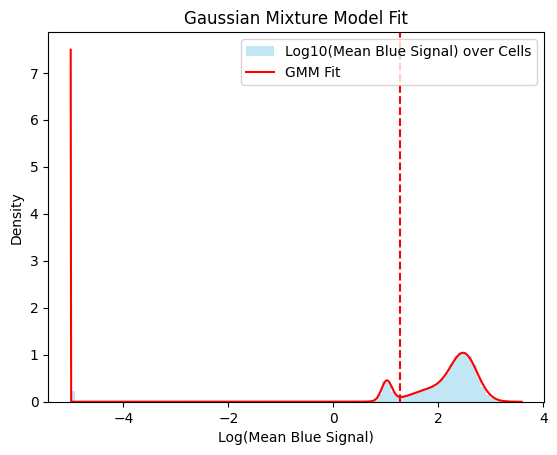

Threshold (log): 1.264664775216168, (linear): 18.393516879968413
Number of effectors: 0.1388593534375495
Number of targets: 0.8611406465624505


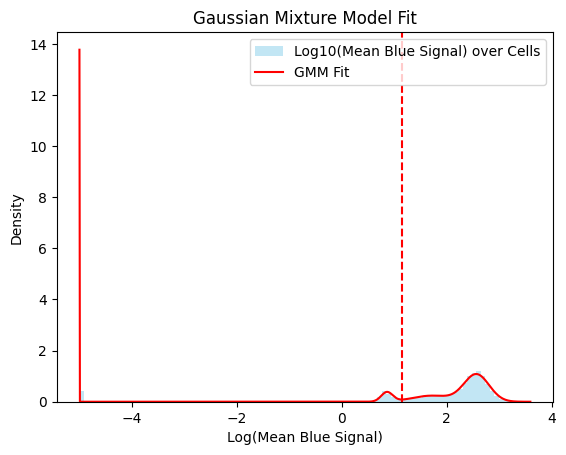

Threshold (log): 1.1410273883810482, (linear): 13.836536350610494
Number of effectors: 0.1468685724505917
Number of targets: 0.8531314275494083
[INFO] Cage metrics are already available for scan 5, lane 1! loading from file
[INFO] Cage metrics are already available for scan 5, lane 2! loading from file
[INFO] Cage metrics are already available for scan 5, lane 3! loading from file
[INFO] Cage metrics are already available for scan 5, lane 4! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 6, lane 1! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 6, lane 2! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 6, lane 3! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 6, lane 4! loading from file


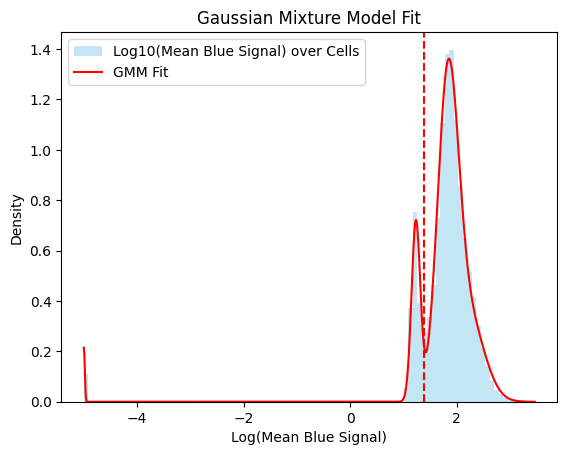

Threshold (log): 1.3929315336974688, (linear): 24.713345096849395
Number of effectors: 0.154061390686991
Number of targets: 0.845938609313009


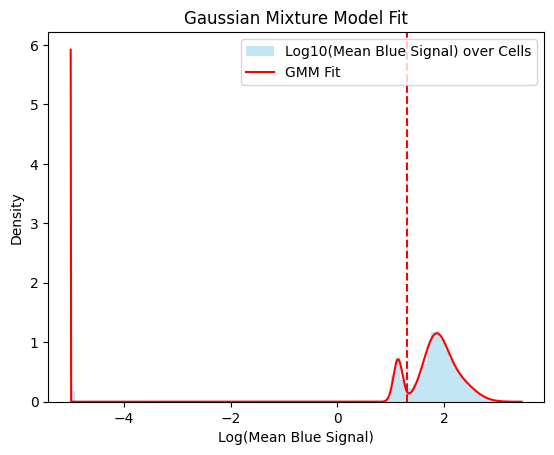

Threshold (log): 1.3090109344460679, (linear): 20.370933659630367
Number of effectors: 0.164877195858263
Number of targets: 0.835122804141737
[INFO] Cage metrics are already available for scan 6, lane 1! loading from file
[INFO] Cage metrics are already available for scan 6, lane 2! loading from file
[INFO] Cage metrics are already available for scan 6, lane 3! loading from file
[INFO] Cage metrics are already available for scan 6, lane 4! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 7, lane 1! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 7, lane 2! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 7, lane 3! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 7, lane 4! loading from file


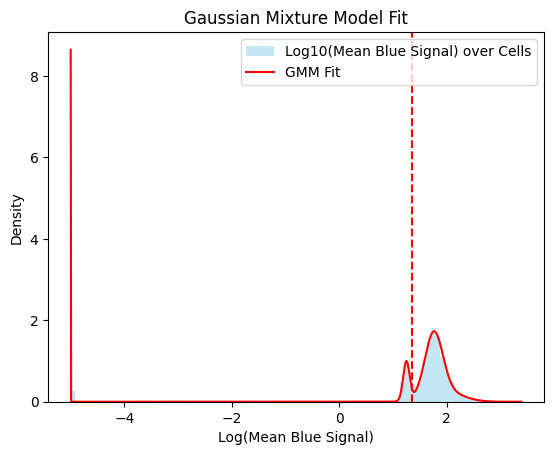

Threshold (log): 1.3647675513980722, (linear): 23.16154636483657
Number of effectors: 0.16864876162608422
Number of targets: 0.8313512383739158


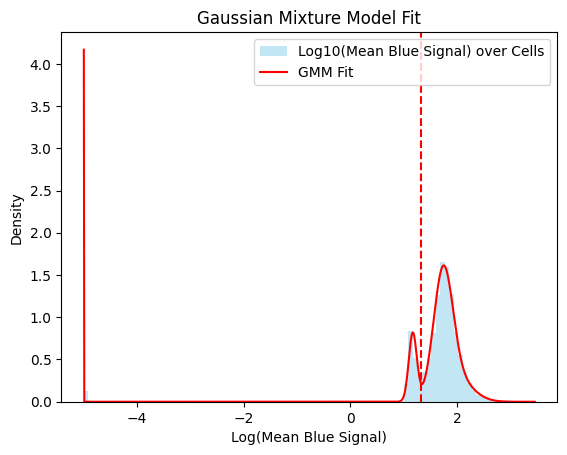

Threshold (log): 1.3203043018240814, (linear): 20.907605736237482
Number of effectors: 0.16371456813870855
Number of targets: 0.8362854318612915
[INFO] Cage metrics are already available for scan 7, lane 1! loading from file
[INFO] Cage metrics are already available for scan 7, lane 2! loading from file
[INFO] Cage metrics are already available for scan 7, lane 3! loading from file
[INFO] Cage metrics are already available for scan 7, lane 4! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 8, lane 1! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 8, lane 2! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 8, lane 3! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 8, lane 4! loading from file


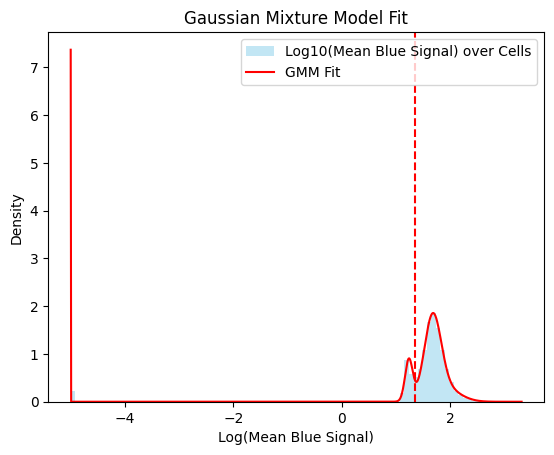

Threshold (log): 1.361548604264937, (linear): 22.99050994206818
Number of effectors: 0.17579888659974577
Number of targets: 0.8242011134002543


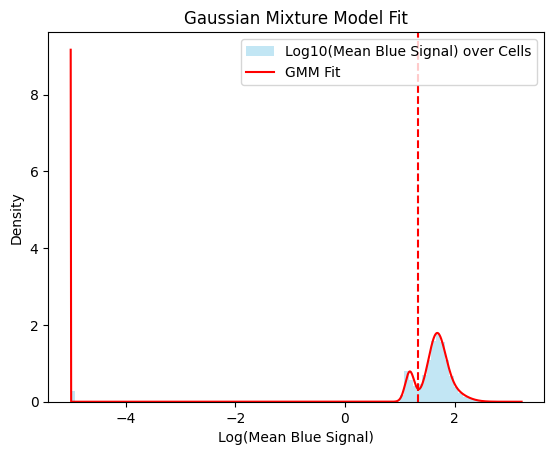

Threshold (log): 1.3327488737015252, (linear): 21.515372707555404
Number of effectors: 0.1853545649898066
Number of targets: 0.8146454350101934
[INFO] Cage metrics are already available for scan 8, lane 1! loading from file
[INFO] Cage metrics are already available for scan 8, lane 2! loading from file
[INFO] Cage metrics are already available for scan 8, lane 3! loading from file
[INFO] Cage metrics are already available for scan 8, lane 4! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 9, lane 1! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 9, lane 2! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 9, lane 3! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 9, lane 4! loading from file


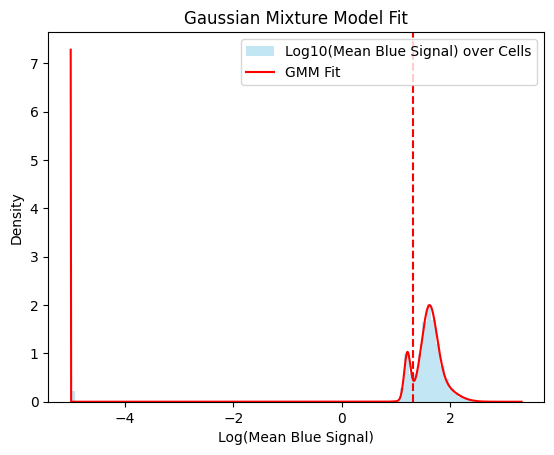

Threshold (log): 1.3060685955881153, (linear): 20.233387340856503
Number of effectors: 0.1656336573226276
Number of targets: 0.8343663426773724


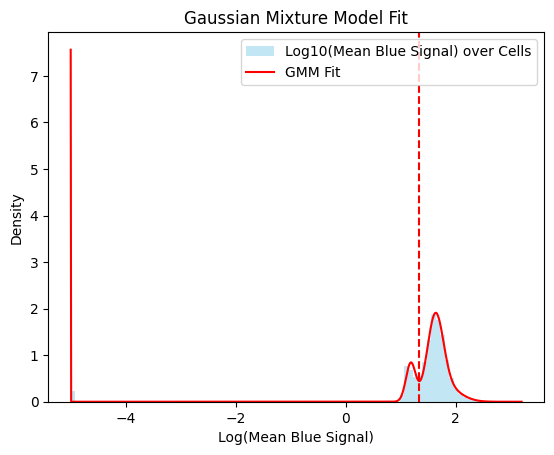

Threshold (log): 1.333309051991957, (linear): 21.543142392686466
Number of effectors: 0.20365325610070828
Number of targets: 0.7963467438992917
[INFO] Cage metrics are already available for scan 9, lane 1! loading from file
[INFO] Cage metrics are already available for scan 9, lane 2! loading from file
[INFO] Cage metrics are already available for scan 9, lane 3! loading from file
[INFO] Cage metrics are already available for scan 9, lane 4! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 10, lane 1! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 10, lane 2! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 10, lane 3! loading from file
[INFO] Fluorescent signal stats per cell are already available for scan 10, lane 4! loading from file


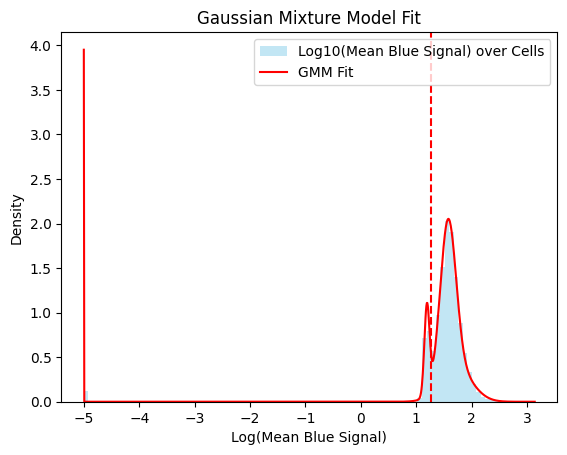

Threshold (log): 1.2710156855343928, (linear): 18.6644710060552
Number of effectors: 0.13808953326324538
Number of targets: 0.8619104667367546


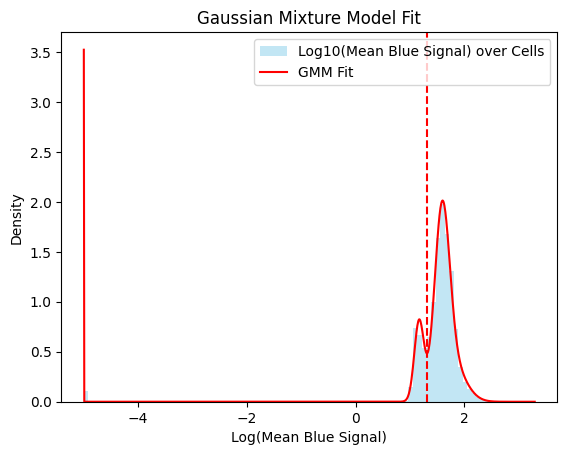

Threshold (log): 1.3131793174841713, (linear): 20.56739635664265
Number of effectors: 0.18783803537494517
Number of targets: 0.8121619646250549
[INFO] Cage metrics are already available for scan 10, lane 1! loading from file
[INFO] Cage metrics are already available for scan 10, lane 2! loading from file
[INFO] Cage metrics are already available for scan 10, lane 3! loading from file
[INFO] Cage metrics are already available for scan 10, lane 4! loading from file


In [3]:
cages_metric_for_all_scans_and_lanes: Dict[int, Dict[int, Dict[str, pd.DataFrame]]] = {}
fl_thresholds: Dict[int, Dict[int, Dict[int, Dict[str, float]]]] = {}

for scan_id in [SCAN_ID_FOR_INSTANCE_SEGMENTATION] + SCAN_IDS:
    cages_metric_for_all_scans_and_lanes[scan_id], fl_thresholds[scan_id] = prepare_data_for_scan(
        exp_base_path=EXP_BASE_PATH, 
        scan_id=scan_id,
        lane_ids_list=LANE_IDS,
        fl_channels_list=FL_CHANNELS_LIST,
        fl_channels_list_for_gating=FL_CHANNELS_LIST_FOR_GATING,
        fl_channels_list_for_metric_extraction=FL_CHANNELS_LIST_FOR_METRIC_EXTRACTION,
        control_lane_to_experiment_lane_map=CONTROL_LANE_TO_EXP_LANE_MAP,
        inst_segmentor_model=inst_segmentor,
        sem_segmentor_model=sem_segmentor,
        return_avg_of_log_fl_values=USE_AVG_OF_LOG_FL_SIGNALS,
        log_gating_threshold_overwrite_dict={'Red': 1.45}
    )

## Data clean up
Cleaning up the metrics, merge the Mask R-CNN scan with other scans.

### Some helper functions

In [4]:
def get_merged_cages_metrics(
    scan_id: int, 
    ref_scan_id: int, 
    exp_lane_id: int, 
    control_lane_id: int, 
    cages_metric_for_all_scans_and_lanes: Dict[int, Dict[int, Dict[str, pd.DataFrame]]],
): 
    only_return_all_metrics: bool = False
    if control_lane_id not in CONTROL_LANE_TO_EXP_LANE_MAP or exp_lane_id != CONTROL_LANE_TO_EXP_LANE_MAP[control_lane_id]:
        # we cannot use any gated metric as the thresholds for gating are used in a specific experiment-control lane mapping
        print(f"[WARN]: The provided control: experiment lanes {control_lane_id}: {exp_lane_id} is not consistent with the "
              f" experiment setup {CONTROL_LANE_TO_EXP_LANE_MAP}! Only all metrics (without gating) will be available for the lanes.")
        only_return_all_metrics = True
    
    exp_cages_metrics: Dict[str, pd.DataFrame] = cages_metric_for_all_scans_and_lanes[scan_id][exp_lane_id]
    exp_ref_cages_metrics: Dict[str, pd.DataFrame] = cages_metric_for_all_scans_and_lanes[ref_scan_id][exp_lane_id]
    control_cages_metrics: Dict[str, pd.DataFrame] = cages_metric_for_all_scans_and_lanes[scan_id][control_lane_id]
    control_ref_cages_metrics: Dict[str, pd.DataFrame] = cages_metric_for_all_scans_and_lanes[ref_scan_id][control_lane_id]
    
    if only_return_all_metrics:
        # only return all metrics
        exp_cages_metrics = {'all': exp_cages_metrics['all']}
        exp_ref_cages_metrics = {'all': exp_ref_cages_metrics['all']}
        control_cages_metrics = {'all': control_cages_metrics['all']}
        control_ref_cages_metrics = {'all': control_ref_cages_metrics['all']}
        
    # merge the cages metrics for the provided scan with the Mask R-CNN metrics, for both experiment and control lanes
    print(f"[INFO] Merging the experiment lane for scan {scan_id}:")
    exp_merged_cages_metrics = merge_cages_metrics_dataframes_using_cage_coords(
        cages_metrics=exp_cages_metrics, 
        ref_cages_metrics=exp_ref_cages_metrics,
        columns_to_include=['num_pixels', 'total_Red_pixel', 'avg_Red_pixel', 'num_Red_positive_pixel', 'fov_filename'], # 'total_Green_pixel', 'avg_Green_pixel'],
        columns_to_include_from_ref=['num_cells', 'cage_xtl', 'cage_ytl', 'cage_xbr', 'cage_ybr', 'fov_filename']
    )

    print(f"[INFO] Merging the control lane for scan {scan_id}:")
    control_merged_cages_metrics = merge_cages_metrics_dataframes_using_cage_coords(
        cages_metrics=control_cages_metrics, 
        ref_cages_metrics=control_ref_cages_metrics,
        columns_to_include=['num_pixels', 'total_Red_pixel', 'avg_Red_pixel', 'num_Red_positive_pixel', 'fov_filename'], # 'total_Green_pixel', 'avg_Green_pixel'],
        columns_to_include_from_ref=['num_cells', 'cage_xtl', 'cage_ytl', 'cage_xbr', 'cage_ybr', 'fov_filename']
    )

    # add scan_id and type of the lane to all the merged dataframes
    for key in exp_merged_cages_metrics.keys():
        control_merged_cages_metrics[key]['scan_id'] = scan_id
        control_merged_cages_metrics[key]['lane_type'] = 'Control'
        exp_merged_cages_metrics[key]['scan_id'] = scan_id
        exp_merged_cages_metrics[key]['lane_type'] = 'Experiment'
    
    return control_merged_cages_metrics, exp_merged_cages_metrics

def clean_up_cages_metrics(in_merged_cages_metrics: pd.DataFrame, 
                           metric: str, 
                           num_scans: int, 
                           log_max_variations_between_scans: float, 
                           log_scale: bool=True):

    merged_cages_metrics = in_merged_cages_metrics.copy()
    
    for key in merged_cages_metrics.keys():
        # keep the cages with num_pixels > 0 and avg_Red_pixel/avg_Green_pixel available (not Nan) for all number of scans
        # also drop the cages with total signal readout zero
        merged_cages_metrics[key] = merged_cages_metrics[key][merged_cages_metrics[key]['num_pixels'] > 0].reset_index(drop=True)
        if log_scale:
            merged_cages_metrics[key] = merged_cages_metrics[key][merged_cages_metrics[key][metric].notnull()].reset_index(drop=True)
        else:
            merged_cages_metrics[key] = merged_cages_metrics[key][merged_cages_metrics[key][metric] > 0].reset_index(drop=True)
        
        num_scans_per_cage = merged_cages_metrics[key].groupby('cage_id')['scan_id'].apply(len)
        cage_ids_to_keep = num_scans_per_cage[num_scans_per_cage == num_scans].index.values
        merged_cages_metrics[key] = merged_cages_metrics[key][
        merged_cages_metrics[key]['cage_id'].apply(lambda x: True if x in cage_ids_to_keep else False)
        ].reset_index(drop=True)

        # remove cages with high varitions between the metric readouts
        # the value of the metrics are in logarithim
        if log_scale:
            signal_dynamic_range_per_cage = merged_cages_metrics[key].groupby('cage_id')[metric].apply(lambda x: x.max() - x.min())
            cage_ids_to_keep = signal_dynamic_range_per_cage[signal_dynamic_range_per_cage < log_max_variations_between_scans].index.values
        else:
            signal_dynamic_range_per_cage = merged_cages_metrics[key].groupby('cage_id')[metric].apply(lambda x: x.max() / x.min())
            cage_ids_to_keep = signal_dynamic_range_per_cage[
            signal_dynamic_range_per_cage < 10 ** log_max_variations_between_scans
            ].index.values
        
        
        merged_cages_metrics[key] = merged_cages_metrics[key][
        merged_cages_metrics[key]['cage_id'].apply(lambda x: True if x in cage_ids_to_keep else False)
        ].reset_index(drop=True)
    
    return merged_cages_metrics

## Analytics

In [5]:
EXP_LANE_TO_USE: int = 4
CONTROL_LANE_TO_USE: int = 3

GATING_TO_USE: str = 'all'

METRIC_TO_USE: str ='avg_Red_pixel'
METRIC_TO_USE_DESC: str = 'Average log of Red signal per pixel'

ONLY_USE_CAGES_WITH_SINGLE_EFFECTOR: bool = False

NORMALIZE_NUM_CELLS_HIST: bool = False


# only used for plotting when both lanes to compare are control lanes
# obviously, only 'all' can be used for GATING_TO_USE
BOTH_CONTROL_LANES: bool = False
if (CONTROL_LANE_TO_USE in CONTROL_LANE_TO_EXP_LANE_MAP and 
    EXP_LANE_TO_USE in CONTROL_LANE_TO_EXP_LANE_MAP):
    BOTH_CONTROL_LANES: bool = True

GATED_METRICS_AVAILABLE: bool = True
if (CONTROL_LANE_TO_USE not in CONTROL_LANE_TO_EXP_LANE_MAP or 
    EXP_LANE_TO_USE != CONTROL_LANE_TO_EXP_LANE_MAP[CONTROL_LANE_TO_USE]):
    # we cannot use any gated metric as the thresholds for gating are used in a specific experiment-control lane mapping
    print(f"[WARN]: The provided control to experiment lane mapping {CONTROL_LANE_TO_USE}: {EXP_LANE_TO_USE} is not consistent with the "
          f" experiment setup {CONTROL_LANE_TO_EXP_LANE_MAP}! Only 'all' metrics (without gating) will be available for the lanes.")
    GATED_METRICS_AVAILABLE = False
    if GATING_TO_USE != 'all':
        print(f"[ERROR]: GATING_TO_USE is set to {GATING_TO_USE} but gating is not possible! GATING_TO_USE will be set to 'all'")
        GATING_TO_USE = 'all'
        
    
if ONLY_USE_CAGES_WITH_SINGLE_EFFECTOR and not GATED_METRICS_AVAILABLE:
    print(f"[ERROR]: The provided control to experiment lane mapping is not consisten with the setup! Impossible to gate effector cells! "
          f"ONLY_USE_CAGES_WITH_SINGLE_EFFECTOR will be set to False")
    ONLY_USE_CAGES_WITH_SINGLE_EFFECTOR = False



if GATING_TO_USE == 'all':
    NUM_CELLS_RANGE = [2, 16]
else:
    NUM_CELLS_RANGE = [1, 16]


In [6]:
control_merged_cages_metrics = {}
exp_merged_cages_metrics = {}

for scan_id in [SCAN_ID_FOR_INSTANCE_SEGMENTATION] + SCAN_IDS:
    control_merged_df_dict, exp_merged_df_dict = get_merged_cages_metrics(
        scan_id=scan_id,
        ref_scan_id=SCAN_ID_FOR_INSTANCE_SEGMENTATION,
        exp_lane_id=EXP_LANE_TO_USE, 
        control_lane_id=CONTROL_LANE_TO_USE,
        cages_metric_for_all_scans_and_lanes=cages_metric_for_all_scans_and_lanes,
    )
    
    for key in exp_merged_df_dict.keys():
        if key in exp_merged_cages_metrics:
            control_merged_cages_metrics[key] = pd.concat(
                [control_merged_cages_metrics[key], control_merged_df_dict[key]]
            ).reset_index(drop=True)
            exp_merged_cages_metrics[key] = pd.concat(
                [exp_merged_cages_metrics[key], exp_merged_df_dict[key]]
            ).reset_index(drop=True)
        else:
            control_merged_cages_metrics[key] = control_merged_df_dict[key]
            exp_merged_cages_metrics[key] = exp_merged_df_dict[key]

[INFO] Merging the experiment lane for scan 5:
Successfully paired 5339 cages out of 5339!
[INFO] Merging the control lane for scan 5:
Successfully paired 5841 cages out of 5841!
[INFO] Merging the experiment lane for scan 6:
Successfully paired 5312 cages out of 5338!
[INFO] Merging the control lane for scan 6:
Successfully paired 5819 cages out of 5836!
[INFO] Merging the experiment lane for scan 7:
Successfully paired 5311 cages out of 5338!
[INFO] Merging the control lane for scan 7:
Successfully paired 5815 cages out of 5838!
[INFO] Merging the experiment lane for scan 8:
Successfully paired 5307 cages out of 5339!
[INFO] Merging the control lane for scan 8:
Successfully paired 5805 cages out of 5839!
[INFO] Merging the experiment lane for scan 9:
Successfully paired 5294 cages out of 5340!
[INFO] Merging the control lane for scan 9:
Successfully paired 5807 cages out of 5836!
[INFO] Merging the experiment lane for scan 10:
Successfully paired 5294 cages out of 5341!
[INFO] Mergin

In [7]:
# keep the cages with num_pixels > 0 and avg_Red_pixel/avg_Green_pixel available (not Nan) for all number of scans
# also drop the cages with total signal readout zero
exp_merged_cages_metrics = clean_up_cages_metrics(
    in_merged_cages_metrics=exp_merged_cages_metrics, 
    metric=METRIC_TO_USE,
    num_scans=len(SCAN_IDS) + 1, 
    log_max_variations_between_scans= np.log10(200)
)
# control lane
control_merged_cages_metrics = clean_up_cages_metrics(
    in_merged_cages_metrics=control_merged_cages_metrics,
    metric=METRIC_TO_USE,
    num_scans=len(SCAN_IDS) + 1, 
    log_max_variations_between_scans= np.log10(200)
)

In [8]:
if ONLY_USE_CAGES_WITH_SINGLE_EFFECTOR:
    df = exp_merged_cages_metrics['Blue_negative'].groupby('scan_id').get_group(SCAN_ID_FOR_INSTANCE_SEGMENTATION)
    exp_cage_ids_with_one_effector: np.ndarray = df.loc[df['num_cells']==1, 'cage_id'].values

    df = control_merged_cages_metrics['Blue_negative'].groupby('scan_id').get_group(SCAN_ID_FOR_INSTANCE_SEGMENTATION)
    control_cage_ids_with_one_effector: np.ndarray = df.loc[df['num_cells']==1, 'cage_id'].values

    for key in exp_merged_cages_metrics.keys():
        exp_merged_cages_metrics[key] = exp_merged_cages_metrics[key][
        exp_merged_cages_metrics[key].apply(lambda x: True if x['cage_id'] in exp_cage_ids_with_one_effector else False, axis=1)
        ].reset_index(drop=True) 
        control_merged_cages_metrics[key] = control_merged_cages_metrics[key][
        control_merged_cages_metrics[key].apply(lambda x: True if x['cage_id'] in control_cage_ids_with_one_effector else False, axis=1)
        ].reset_index(drop=True) 

In [9]:
print(f"Unique num scans per control cage: {control_merged_cages_metrics[GATING_TO_USE].groupby('cage_id')['scan_id'].apply(len).unique()}")
print(f"Unique num scans per experiment cage: {exp_merged_cages_metrics[GATING_TO_USE].groupby('cage_id')['scan_id'].apply(len).unique()}")
print(f"Num control cages: {control_merged_cages_metrics[GATING_TO_USE].groupby('cage_id')['scan_id'].apply(len).value_counts().values[0]}")
print(f"Num experiment cages: {exp_merged_cages_metrics[GATING_TO_USE].groupby('cage_id')['scan_id'].apply(len).value_counts().values[0]}") 

Unique num scans per control cage: [6]
Unique num scans per experiment cage: [6]
Num control cages: 5080
Num experiment cages: 4520


In [10]:
if NORMALIZE_NUM_CELLS_HIST:
    import random
    random.seed(7)

    exp_cage_ids = []
    control_cage_ids = []

    s1 = exp_merged_cages_metrics[GATING_TO_USE].groupby('num_cells')['cage_id'].apply(np.unique)
    s2 = control_merged_cages_metrics[GATING_TO_USE].groupby('num_cells')['cage_id'].apply(np.unique)

    for num_cell in list(set(s1.index.values.tolist() + s2.index.values.tolist())):
        if num_cell not in s1.index or num_cell not in s2.index:
            continue
        
        exp_cage_ids_for_this_num_cell = s1[num_cell]
        control_cage_ids_for_this_num_cell = s2[num_cell]
        
        n = min(len(exp_cage_ids_for_this_num_cell), len(control_cage_ids_for_this_num_cell))
    
        random.shuffle(exp_cage_ids_for_this_num_cell)
        random.shuffle(control_cage_ids_for_this_num_cell)
        
        exp_cage_ids += exp_cage_ids_for_this_num_cell[:n].tolist()
        control_cage_ids += control_cage_ids_for_this_num_cell[:n].tolist()
    
    exp_merged_cages_metrics[GATING_TO_USE] = exp_merged_cages_metrics[GATING_TO_USE][
    exp_merged_cages_metrics[GATING_TO_USE]['cage_id'].apply(lambda x: True if x in exp_cage_ids else False)
    ].reset_index(drop=True)
    control_merged_cages_metrics[GATING_TO_USE] = control_merged_cages_metrics[GATING_TO_USE][
    control_merged_cages_metrics[GATING_TO_USE]['cage_id'].apply(lambda x: True if x in control_cage_ids else False)
    ].reset_index(drop=True)

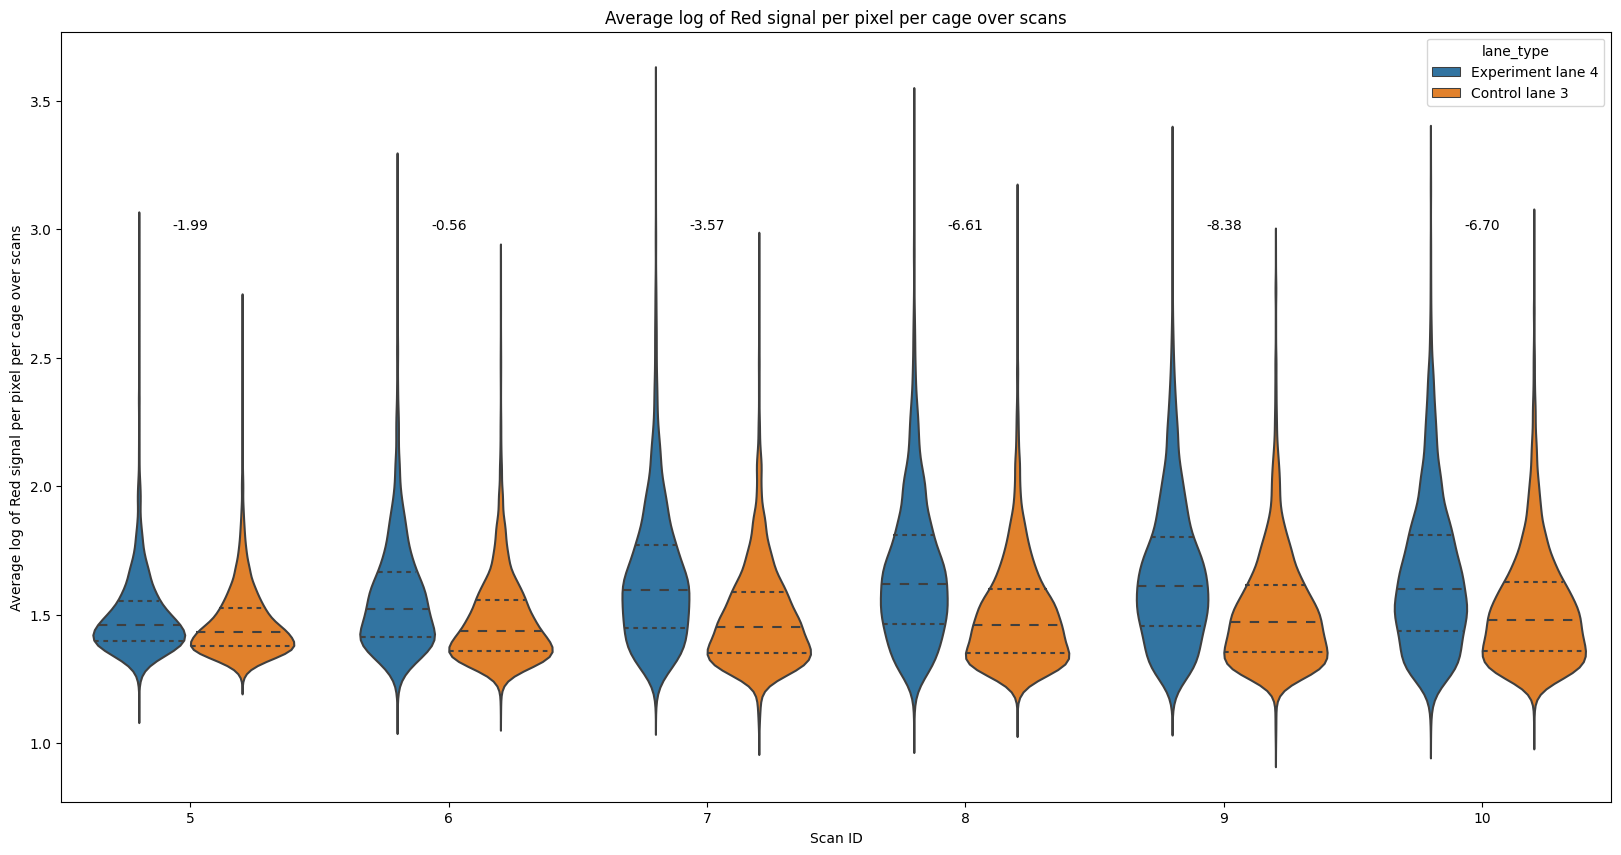

In [11]:
df_for_plot = pd.concat([exp_merged_cages_metrics[GATING_TO_USE], control_merged_cages_metrics[GATING_TO_USE]])

# convert the average values to logarithmic scale
# df_for_plot[METRIC_TO_USE] = df_for_plot[METRIC_TO_USE].apply(np.log10)

if BOTH_CONTROL_LANES:
    exp_lane_type_str: str = 'Control lane ' + str(EXP_LANE_TO_USE)
    control_lane_type_str = 'Control lane ' + str(CONTROL_LANE_TO_USE)
else:
    exp_lane_type_str: str = 'Experiment lane ' + str(EXP_LANE_TO_USE)
    control_lane_type_str: str = 'Control lane ' + str(CONTROL_LANE_TO_USE)

df_for_plot.loc[df_for_plot['lane_type'] == 'Experiment', 'lane_type'] = exp_lane_type_str
df_for_plot.loc[df_for_plot['lane_type'] == 'Control', 'lane_type'] = control_lane_type_str

k_s_p_values: List[float] = []
# Kolmogorov-Smirnov (K-S) goodness-of-fit test
for scan_id in [SCAN_ID_FOR_INSTANCE_SEGMENTATION] + SCAN_IDS:
    x = df_for_plot.groupby('scan_id').get_group(scan_id).groupby('lane_type').get_group(exp_lane_type_str)[METRIC_TO_USE].values
    y = df_for_plot.groupby('scan_id').get_group(scan_id).groupby('lane_type').get_group(control_lane_type_str)[METRIC_TO_USE].values
    # subtract the means and normalize both samples with standard deviation to only compare the shapes of the distributions
    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)
    test_results = ks_2samp(x, y)
    k_s_p_values.append(test_results.pvalue)

# create violin plot
fig, ax = plt.subplots(1, figsize=(20, 10))
sn_plot = sn.violinplot(data=df_for_plot, x='scan_id', y=METRIC_TO_USE, hue='lane_type', inner="quartile")

for i in range(len(k_s_p_values)):
    plt.text(i, int(df_for_plot[METRIC_TO_USE].max()), f'{np.log10(k_s_p_values[i]):.2f}', ha='center', color='black')

# ax.set_aspect('equal')
# ax.legend(bbox_to_anchor=(0.9, 0.95), loc=1, borderaxespad=0.0)
plt.xlabel('Scan ID')
plt.ylabel(f"{METRIC_TO_USE_DESC} per cage over scans")
plt.title(f"{METRIC_TO_USE_DESC} per cage over scans")

plt.show()

In [12]:
df = exp_merged_cages_metrics[GATING_TO_USE].groupby('cage_id')[METRIC_TO_USE].apply(np.stack).reset_index().set_index('cage_id')
exp_metric_per_cage: np.ndarray = np.array([l for l in df[METRIC_TO_USE].values])
# exp_metric_per_cage = np.log10(exp_metric_per_cage)

df = control_merged_cages_metrics[GATING_TO_USE].groupby('cage_id')[METRIC_TO_USE].apply(np.stack).reset_index().set_index('cage_id')
control_metric_per_cage: np.ndarray = np.array([l for l in df[METRIC_TO_USE].values])
# control_metric_per_cage = np.log10(control_metric_per_cage)

In [13]:
print(control_metric_per_cage.shape)
print(exp_metric_per_cage.shape)

(5080, 6)
(4520, 6)


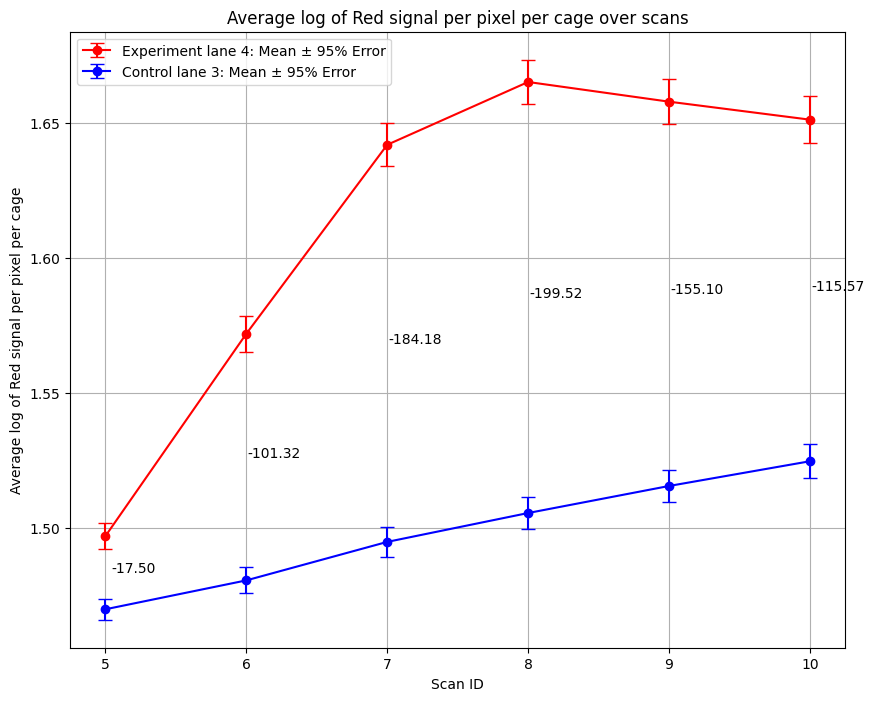

In [14]:
# Calculate mean and standard deviation for each column
control_means = np.mean(control_metric_per_cage, axis=0)
control_std_devs = np.std(control_metric_per_cage, axis=0)
num_control_samples = control_metric_per_cage.shape[0]

exp_means = np.mean(exp_metric_per_cage, axis=0)
exp_std_devs = np.std(exp_metric_per_cage, axis=0)
num_exp_samples = exp_metric_per_cage.shape[0]

x = [SCAN_ID_FOR_INSTANCE_SEGMENTATION] + SCAN_IDS

p_values = np.zeros_like(x, dtype=float)
for i, scan_id in enumerate(x):
    set_1 = control_metric_per_cage[:, i]
    set_2 = exp_metric_per_cage[:, i]
    # Welch's t-test
    t_statistic, p_value = ttest_ind(set_1, set_2, equal_var=False)
    p_values[i] = np.round(np.log10(p_value), 2)

fig, ax = plt.subplots(1, figsize=(10, 8))

if BOTH_CONTROL_LANES:
    exp_label = 'Control lane ' + str(EXP_LANE_TO_USE) + ': Mean ± 95% Error'
    control_label = 'Control lane ' + str(CONTROL_LANE_TO_USE) + ': Mean ± 95% Error'
else:
    exp_label = 'Experiment lane ' + str(EXP_LANE_TO_USE) + ': Mean ± 95% Error'
    control_label = 'Control lane ' + str(CONTROL_LANE_TO_USE) + ': Mean ± 95% Error'

# Plot mean with error bars representing standard deviation
plt.errorbar(x, exp_means, yerr=1.96 * exp_std_devs / np.sqrt(num_exp_samples), fmt='r-o', capsize=5, label=exp_label)
plt.errorbar(x, control_means, yerr=1.96 * control_std_devs / np.sqrt(num_control_samples), fmt='b-o', capsize=5, label=control_label)

for i in range(len(x)):
    plt.text(x[i]+0.2, (exp_means[i] + control_means[i]) / 2, f'{p_values[i]:.2f}', ha='center', color='black')


# Add labels and title
plt.xlabel('Scan ID')
plt.ylabel(f"{METRIC_TO_USE_DESC} per cage")
plt.title(f"{METRIC_TO_USE_DESC} per cage over scans")
plt.legend()
plt.grid(True)
plt.show()

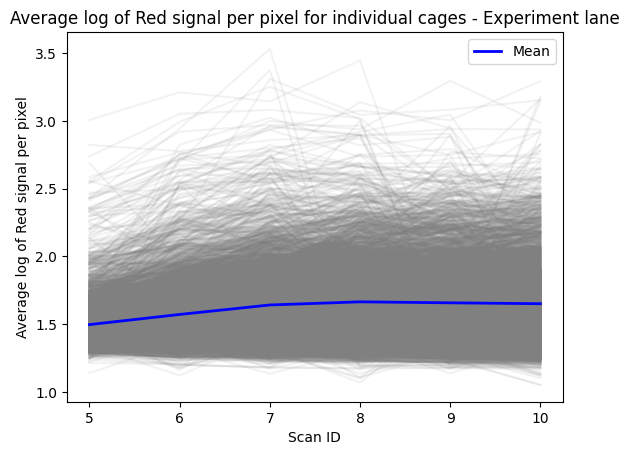

In [15]:
# Plot each row with transparency
x = [SCAN_ID_FOR_INSTANCE_SEGMENTATION] + SCAN_IDS
for row in exp_metric_per_cage:
    plt.plot(x, row, color='gray', alpha=0.1)

# Plot the mean line on top for reference
plt.plot(x, exp_means, color='blue', linewidth=2, label='Mean')

plt.xlabel('Scan ID')
plt.ylabel(f"{METRIC_TO_USE_DESC}")
plt.title(f"{METRIC_TO_USE_DESC} for individual cages - Experiment lane")
plt.legend()
plt.show()

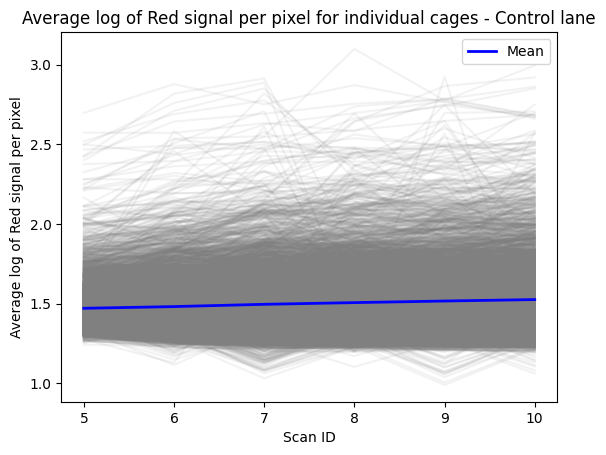

In [16]:
# Plot each row with transparency
x = [SCAN_ID_FOR_INSTANCE_SEGMENTATION] + SCAN_IDS
for row in control_metric_per_cage:
    plt.plot(x, row, color='gray', alpha=0.1)

# Plot the mean line on top for reference
plt.plot(x, control_means, color='blue', linewidth=2, label='Mean')

plt.xlabel('Scan ID')
plt.ylabel(f"{METRIC_TO_USE_DESC}")
plt.title(f"{METRIC_TO_USE_DESC} for individual cages - Control lane")
plt.legend()
plt.show()

In [17]:
# set the highest average Red observed over time
def find_scan_id_with_highest_metric(in_merged_cages_metrics, metric, max_index=len(SCAN_IDS)+1):
    merged_cages_metrics = in_merged_cages_metrics.copy()
    for key in merged_cages_metrics.keys():
        df = merged_cages_metrics[key].groupby('cage_id')[metric].apply(lambda x: np.max(x[:max_index])).reset_index()
        df.rename(columns={metric: 'highest_' + metric + '_over_scans'}, inplace=True)
        merged_cages_metrics[key] = merged_cages_metrics[key].merge(df, on='cage_id', suffixes=('', '_ref'))
        
        # set the scan ID for the highest average Red observed over time
        df = merged_cages_metrics[key].groupby('cage_id')[[metric, 'scan_id']].apply(lambda x: x['scan_id'].values[np.argmax(x[metric][:max_index])]).reset_index()
        df.rename(columns={0: 'scan_id_with_highest_' + metric}, inplace=True)
        merged_cages_metrics[key] = merged_cages_metrics[key].merge(df, on='cage_id', suffixes=('', '_ref'))

    return merged_cages_metrics


In [18]:
exp_merged_cages_metrics = find_scan_id_with_highest_metric(in_merged_cages_metrics=exp_merged_cages_metrics, metric=METRIC_TO_USE)
# exp_merged_cages_metrics = find_scan_id_with_highest_metric(in_merged_cages_metrics=exp_merged_cages_metrics, metric=METRIC_TO_USE, max_index=4)
control_merged_cages_metrics = find_scan_id_with_highest_metric(in_merged_cages_metrics=control_merged_cages_metrics, metric=METRIC_TO_USE)

In [19]:
exp_df = exp_merged_cages_metrics[GATING_TO_USE][
['num_cells', 'lane_type', 'highest_' + METRIC_TO_USE + '_over_scans', 'scan_id_with_highest_' + METRIC_TO_USE]
].drop_duplicates().reset_index(drop=True)
# exp_df['highest_' + METRIC_TO_USE + '_over_scans'] = exp_df['highest_' + METRIC_TO_USE + '_over_scans'].apply(np.log10)

control_df = control_merged_cages_metrics[GATING_TO_USE][
['num_cells', 'lane_type', 'highest_' + METRIC_TO_USE + '_over_scans', 'scan_id_with_highest_' + METRIC_TO_USE]
].drop_duplicates().reset_index(drop=True)
# control_df['highest_' + METRIC_TO_USE + '_over_scans'] = control_df['highest_' + METRIC_TO_USE + '_over_scans'].apply(np.log10)
df_for_plot = pd.concat([exp_df, control_df]).reset_index(drop=True)

if BOTH_CONTROL_LANES:
    df_for_plot.loc[df_for_plot['lane_type'] == 'Experiment', 'lane_type'] = 'Control lane ' + str(EXP_LANE_TO_USE)
    df_for_plot.loc[df_for_plot['lane_type'] == 'Control', 'lane_type'] = 'Control lane ' + str(CONTROL_LANE_TO_USE)
else:
    df_for_plot.loc[df_for_plot['lane_type'] == 'Experiment', 'lane_type'] = 'Experiment lane ' + str(EXP_LANE_TO_USE)
    df_for_plot.loc[df_for_plot['lane_type'] == 'Control', 'lane_type'] = 'Control lane ' + str(CONTROL_LANE_TO_USE)

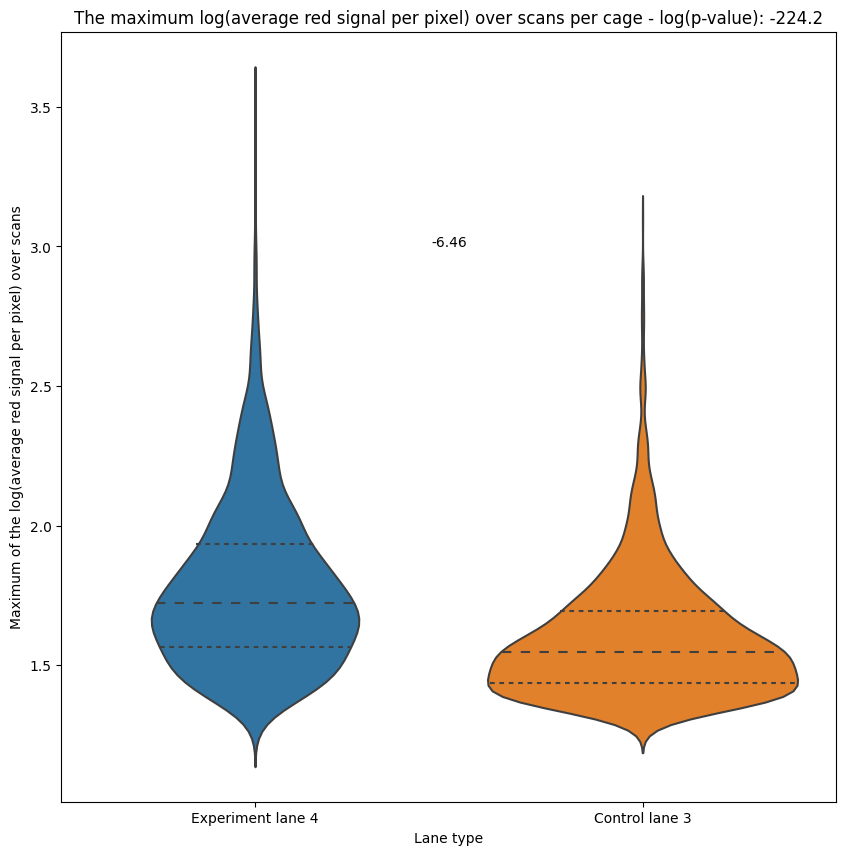

6.309006061136277e-225


In [20]:
# Create violin plot
fig, ax = plt.subplots(1, figsize=(10, 10))

sn_plot = sn.violinplot(data=df_for_plot, x='lane_type', y='highest_' + METRIC_TO_USE + '_over_scans', inner="quartile", )

set_1 = exp_df['highest_' + METRIC_TO_USE + '_over_scans'].values
set_2 = control_df['highest_' + METRIC_TO_USE + '_over_scans'].values
# Welch's t-test
t_statistic, p_value = ttest_ind(set_1, set_2, equal_var=False)
k_s_p_value = ks_2samp((set_1 - np.mean(set_1)) / np.std(set_1), (set_2 - np.mean(set_2)) / np.std(set_2)).pvalue
plt.text(0.5, int(max(set_1.max(), set_2.max())), f'{np.log10(k_s_p_value):.2f}', ha='center', color='black')
# ax.set_aspect('equal')
# ax.legend(bbox_to_anchor=(0.9, 0.95), loc=1, borderaxespad=0.0)
plt.xlabel('Lane type')
plt.ylabel('Maximum of the log(average red signal per pixel) over scans')
plt.title(f"The maximum log(average red signal per pixel) over scans per cage - log(p-value): {np.round(np.log10(p_value), 2)}")
plt.show()
print(p_value)

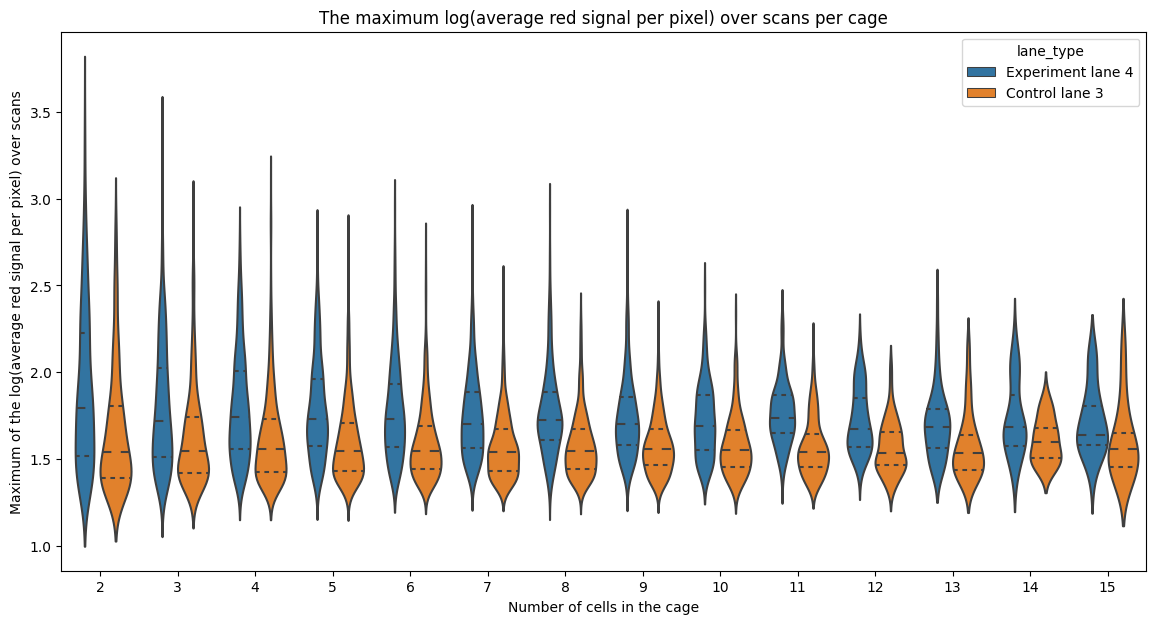

In [21]:
# Create violin plot
fig, ax = plt.subplots(1, figsize=(14, 7))
sn_plot = sn.violinplot(data=df_for_plot, x='num_cells', y='highest_' + METRIC_TO_USE + '_over_scans', hue='lane_type', inner="quartile", 
                        order = [i for i in range(NUM_CELLS_RANGE[0], NUM_CELLS_RANGE[1])]
                       )
# ax.set_aspect('equal')
# ax.legend(bbox_to_anchor=(0.9, 0.95), loc=1, borderaxespad=0.0)
plt.xlabel('Number of cells in the cage')
plt.ylabel('Maximum of the log(average red signal per pixel) over scans')
plt.title('The maximum log(average red signal per pixel) over scans per cage')

plt.show()

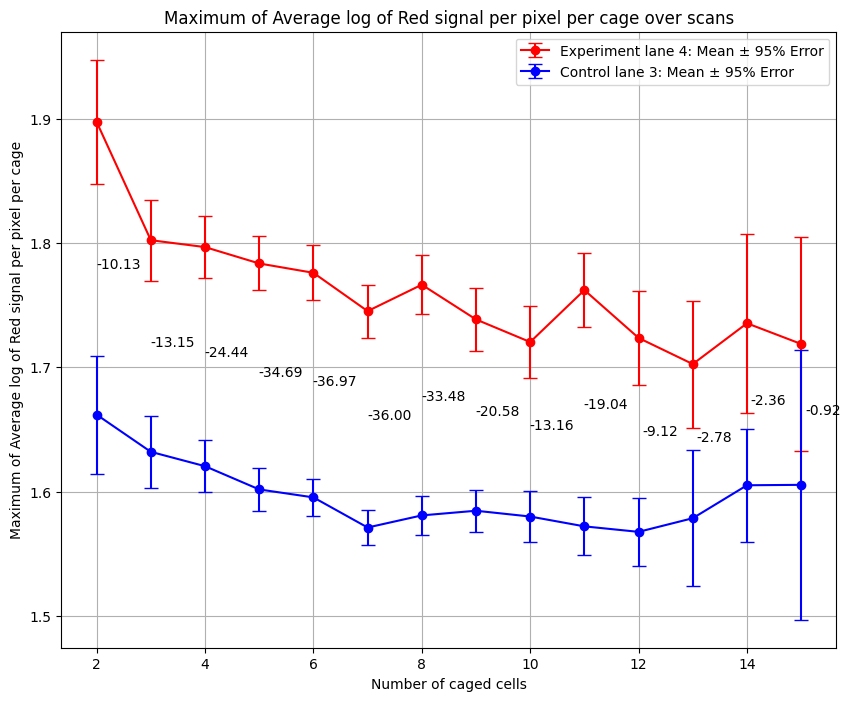

In [22]:
# Calculate mean and standard deviation for each column
control_means = control_df.groupby('num_cells')['highest_' + METRIC_TO_USE + '_over_scans'].mean()
control_std_devs = control_df.groupby('num_cells')['highest_' + METRIC_TO_USE + '_over_scans'].std()
control_means = control_means[(NUM_CELLS_RANGE[0] <= control_means.index) & (control_means.index < NUM_CELLS_RANGE[1])]
control_std_devs = control_std_devs[control_means.index]
num_control_samples = control_df.groupby('num_cells')['num_cells'].apply(len)
num_control_samples = num_control_samples[control_means.index]

exp_means = exp_df.groupby('num_cells')['highest_' + METRIC_TO_USE + '_over_scans'].mean()
exp_std_devs = exp_df.groupby('num_cells')['highest_' + METRIC_TO_USE + '_over_scans'].std()
exp_means = exp_means[(NUM_CELLS_RANGE[0] <= exp_means.index) & (exp_means.index < NUM_CELLS_RANGE[1])]
exp_std_devs = exp_std_devs[exp_means.index]
num_exp_samples = exp_df.groupby('num_cells')['num_cells'].apply(len)
num_exp_samples = num_exp_samples[exp_means.index]

control_cage_counts = control_df.groupby('num_cells')['highest_' + METRIC_TO_USE + '_over_scans'].apply(len)
exp_cage_counts = exp_df.groupby('num_cells')['highest_' + METRIC_TO_USE + '_over_scans'].apply(len)

# Create an x-axis for each column
p_values = np.zeros_like(exp_means.index, dtype=float)
for i, num_cells in enumerate(exp_means.index):
    set_1 = control_df.groupby('num_cells')['highest_' + METRIC_TO_USE + '_over_scans'].get_group(num_cells).values
    set_2 = exp_df.groupby('num_cells')['highest_' + METRIC_TO_USE + '_over_scans'].get_group(num_cells).values
    # Welch's t-test
    t_statistic, p_value = ttest_ind(set_1, set_2, equal_var=False)
    p_values[i] = np.log10(p_value)

if BOTH_CONTROL_LANES:
    exp_label = 'Control lane ' + str(EXP_LANE_TO_USE) + ': Mean ± 95% Error'
    control_label = 'Control lane ' + str(CONTROL_LANE_TO_USE) + ': Mean ± 95% Error'
else:
    exp_label = 'Experiment lane ' + str(EXP_LANE_TO_USE) + ': Mean ± 95% Error'
    control_label = 'Control lane ' + str(CONTROL_LANE_TO_USE) + ': Mean ± 95% Error'

x = exp_means.index
fig, ax = plt.subplots(1, figsize=(10, 8))
# Plot mean with error bars representing standard deviation
plt.errorbar(x, exp_means, yerr=1.95 * exp_std_devs.div(num_exp_samples.apply(np.sqrt)), fmt='r-o', capsize=5, label=exp_label)
plt.errorbar(x, control_means, yerr=1.95 * control_std_devs.div(num_control_samples.apply(np.sqrt)), fmt='b-o', capsize=5, label=control_label)

for i in range(len(x)):
    plt.text(x[i]+0.4, (exp_means[x[i]] + control_means[x[i]]) / 2, f'{p_values[i]:.2f}', ha='center', color='black')


# Add labels and title
# Add labels and title
plt.xlabel('Number of caged cells')
plt.ylabel(f"Maximum of {METRIC_TO_USE_DESC} per cage")
plt.title(f"Maximum of {METRIC_TO_USE_DESC} per cage over scans")
plt.legend()
plt.grid(True)
plt.show()

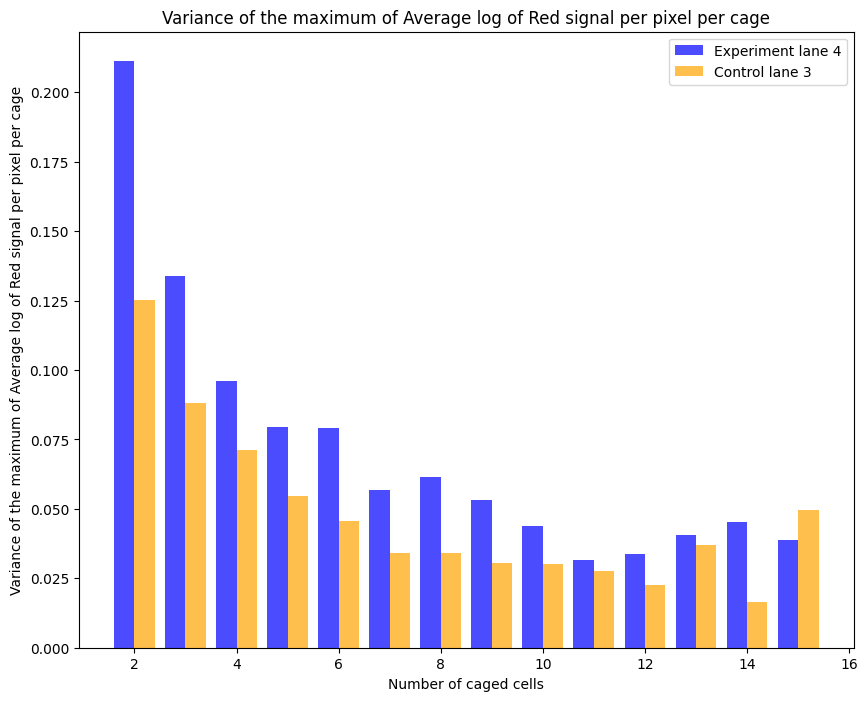

In [23]:
if BOTH_CONTROL_LANES:
    exp_label = 'Control lane ' + str(EXP_LANE_TO_USE) 
    control_label = 'Control lane ' + str(CONTROL_LANE_TO_USE)
else:
    exp_label = 'Experiment lane ' + str(EXP_LANE_TO_USE) 
    control_label = 'Control lane ' + str(CONTROL_LANE_TO_USE) 

fig, ax = plt.subplots(1, figsize=(10, 8))
# Define the width of each bar and the positions for parallel bars
bar_width = 0.4
# Plot the first histogram
plt.bar(x - bar_width / 2, exp_std_devs ** 2, width=bar_width, label=exp_label, color='blue', alpha=0.7)

# Plot the second histogram
plt.bar(x + bar_width / 2, control_std_devs ** 2, width=bar_width, label=control_label, color='orange', alpha=0.7)

# Add labels and legend
plt.xlabel('Number of caged cells')
plt.ylabel(f"Variance of the maximum of {METRIC_TO_USE_DESC} per cage")
plt.legend()
plt.title(f"Variance of the maximum of {METRIC_TO_USE_DESC} per cage")
plt.show()

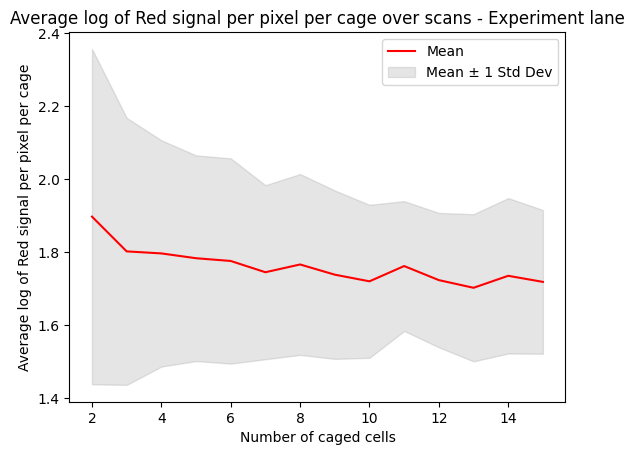

In [24]:
plt.plot(x, exp_means, color='r', label='Mean')

# Plot the standard deviation as a shaded area (mean ± 1 std deviation)
plt.fill_between(x, exp_means - exp_std_devs, exp_means + exp_std_devs, color='gray', alpha=0.2, label='Mean ± 1 Std Dev')

# Add labels and title
plt.xlabel('Number of caged cells')
plt.ylabel(f"{METRIC_TO_USE_DESC} per cage")
plt.title(f"{METRIC_TO_USE_DESC} per cage over scans - Experiment lane")
plt.legend()
plt.show()

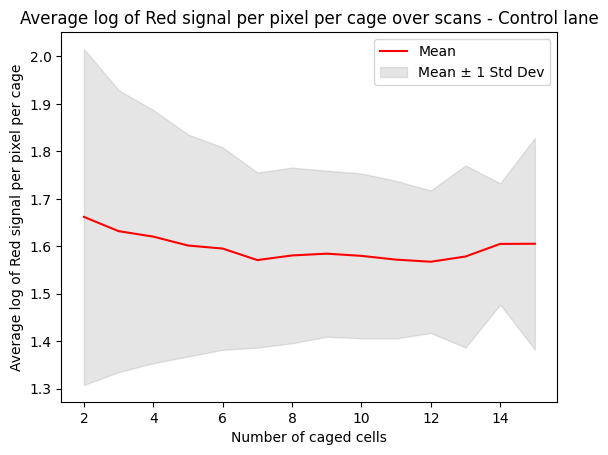

In [25]:
plt.plot(x, control_means, color='r', label='Mean')

# Plot the standard deviation as a shaded area (mean ± 1 std deviation)
plt.fill_between(x, control_means - control_std_devs, control_means + control_std_devs, color='gray', alpha=0.2, label='Mean ± 1 Std Dev')

# Add labels and title
plt.xlabel('Number of caged cells')
plt.ylabel(f"{METRIC_TO_USE_DESC} per cage")
plt.title(f"{METRIC_TO_USE_DESC} per cage over scans - Control lane")
plt.legend()
plt.show()

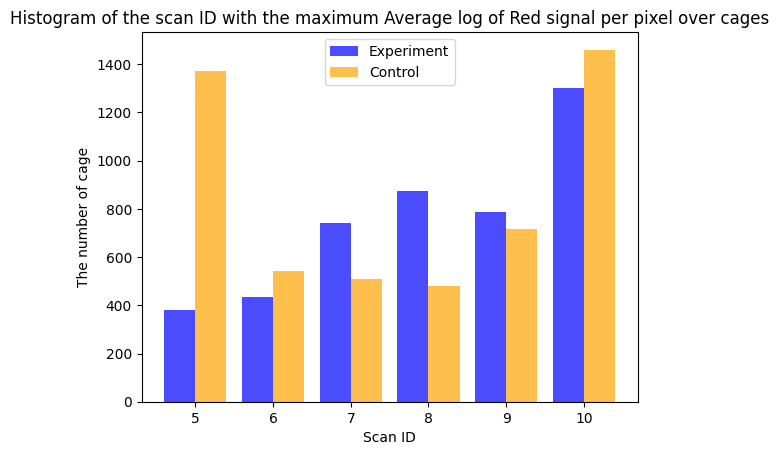

In [26]:
bins = np.array([SCAN_ID_FOR_INSTANCE_SEGMENTATION] + SCAN_IDS) - 0.5
bins = np.hstack([bins, SCAN_IDS[-1] + 0.5])
# Calculate the histogram values for both datasets
hist1, _ = np.histogram(exp_df['scan_id_with_highest_' + METRIC_TO_USE], bins=bins)
hist2, _ = np.histogram(control_df['scan_id_with_highest_' + METRIC_TO_USE], bins=bins)

# Define the width of each bar and the positions for parallel bars
bar_width = 0.4
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Plot the first histogram
plt.bar(bin_centers - bar_width / 2, hist1, width=bar_width, label='Experiment', color='blue', alpha=0.7)

# Plot the second histogram
plt.bar(bin_centers + bar_width / 2, hist2, width=bar_width, label='Control', color='orange', alpha=0.7)

# Add labels and legend
plt.xlabel('Scan ID')
plt.ylabel('The number of cage')
plt.legend()
plt.title(f"Histogram of the scan ID with the maximum {METRIC_TO_USE_DESC} over cages")
plt.show()

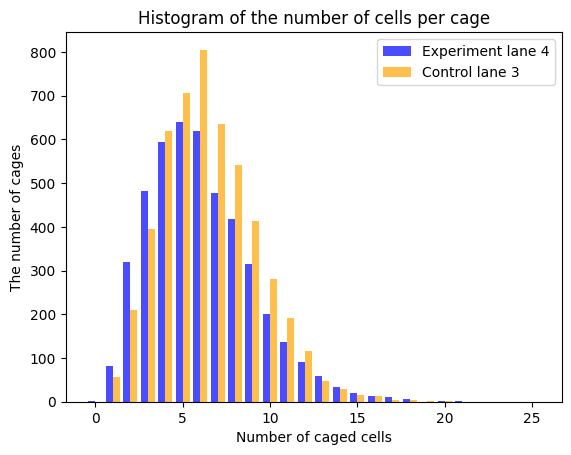

In [27]:
bins = np.arange(27) - 0.5
# Calculate the histogram values for both datasets
hist1, _ = np.histogram(exp_df['num_cells'], bins=bins)
hist2, _ = np.histogram(control_df['num_cells'], bins=bins)

# Define the width of each bar and the positions for parallel bars
bar_width = 0.4
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Plot the first histogram
plt.bar(bin_centers - bar_width / 2, hist1, width=bar_width, label=exp_label, color='blue', alpha=0.7)

# Plot the second histogram
plt.bar(bin_centers + bar_width / 2, hist2, width=bar_width, label=control_label, color='orange', alpha=0.7)

# Add labels and legend
plt.xlabel('Number of caged cells')
plt.ylabel('The number of cages')
plt.legend()
plt.title(f"Histogram of the number of cells per cage")
plt.show()

In [28]:
np.sum(control_df['num_cells']) / np.sum(exp_df['num_cells'])

1.1895996817705132

In [29]:
np.mean(control_df['num_cells'])

6.475590551181102

In [30]:
np.mean(exp_df['num_cells'])

6.117920353982301

In [65]:
def generate_heatmap(exp_merged_cages_metrics, control_merged_cages_metrics, num_cells=None):

    if num_cells is None:
        exp_df = exp_merged_cages_metrics[GATING_TO_USE]
        control_df = control_merged_cages_metrics[GATING_TO_USE]
    else:
        exp_df = exp_merged_cages_metrics[GATING_TO_USE][exp_merged_cages_metrics[GATING_TO_USE]['num_cells'] == num_cells]
        control_df = control_merged_cages_metrics[GATING_TO_USE][control_merged_cages_metrics[GATING_TO_USE]['num_cells'] == num_cells]
    
    pivoted_exp_cages_metrics = exp_df.pivot(index='cage_id', columns='scan_id', values=METRIC_TO_USE)
    # pivoted_exp_cages_metrics = pivoted_exp_cages_metrics.apply(np.log10)
    pivoted_control_cages_metrics = control_df.pivot(index='cage_id', columns='scan_id', values=METRIC_TO_USE)
    # pivoted_control_cages_metrics = pivoted_control_cages_metrics.apply(np.log10)

    # replace the metric value for the later scans with the maximum observed during the experiment
    for i, row in pivoted_exp_cages_metrics.iterrows():
        metrics_over_scans = row.values
        metrics_over_scans[np.argmax(metrics_over_scans):] = np.max(metrics_over_scans)
        pivoted_exp_cages_metrics.loc[i] = metrics_over_scans

    for i, row in pivoted_control_cages_metrics.iterrows():
        metrics_over_scans = row.values
        metrics_over_scans[np.argmax(metrics_over_scans):] = np.max(metrics_over_scans)
        pivoted_control_cages_metrics.loc[i] = metrics_over_scans

    sorted_exp = pivoted_exp_cages_metrics.sort_values(
            by=SCAN_IDS[::-1] + [SCAN_ID_FOR_INSTANCE_SEGMENTATION],
            ascending=False,
            ignore_index=True
        )
    sorted_control = pivoted_control_cages_metrics.sort_values(
            by=SCAN_IDS[::-1] + [SCAN_ID_FOR_INSTANCE_SEGMENTATION],
            ascending=False,
            ignore_index=True
        )
    # norm = Normalize(vmin=min(sorted_exp.min().min(), sorted_control.min().min()), 
    #              vmax=max(sorted_exp.max().max(), sorted_control.max().max()))

    norm = Normalize(vmin=min(sorted_exp.min().min(), sorted_control.min().min()),  
                     vmax=max(np.percentile(sorted_exp.max(axis=1), 95), np.percentile(sorted_control.max(axis=1), 95)))
    fig, ax = plt.subplots(1, 2, figsize=(15, 15))
    # create data
    sn.heatmap(sorted_exp, annot=False, yticklabels=False, ax=ax[0], cmap='Reds', norm=norm)
    
    ax[0].set_title(f"Heatmap of {METRIC_TO_USE_DESC} per cage over scans \n Experiment lane {EXP_LANE_TO_USE}") 
    ax[0].set(ylabel='Cages', xlabel='Scan ID')

    sn.heatmap(sorted_control, annot=False, yticklabels=False, ax=ax[1], cmap='Reds', norm=norm)

    ax[1].set_title(f"Heatmap of {METRIC_TO_USE_DESC} per cage over scans \n Control lane {CONTROL_LANE_TO_USE}") 
    ax[1].set(ylabel='Cages', xlabel='Scan ID')
    plt.show()

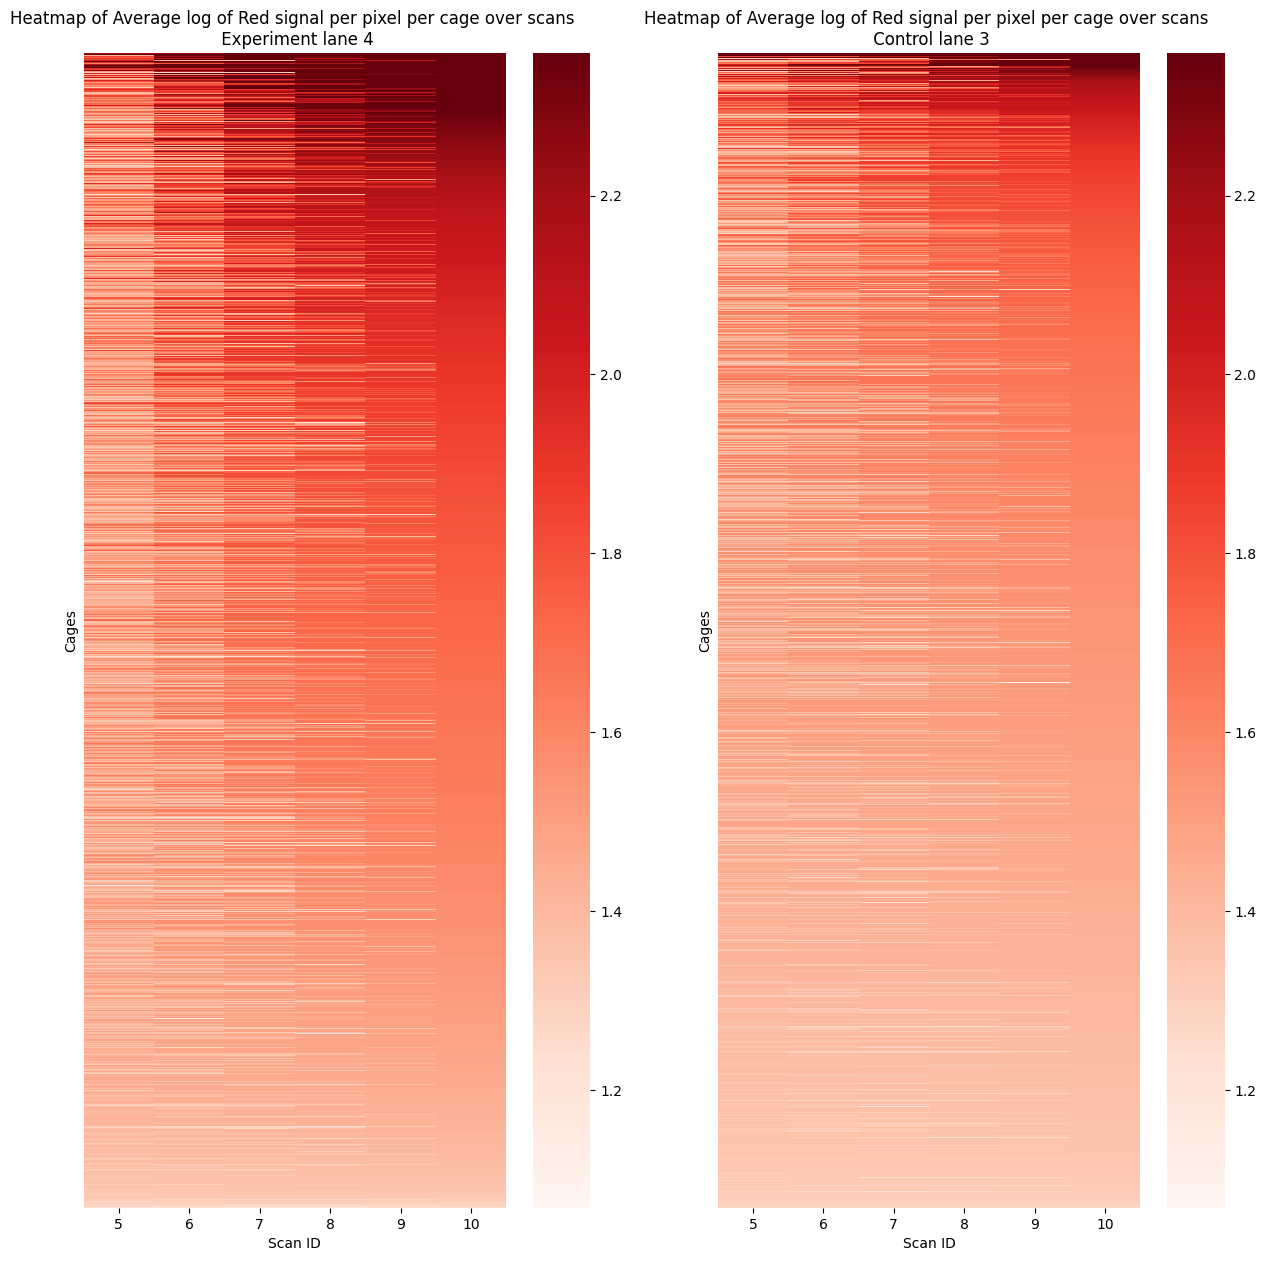

In [66]:
generate_heatmap(exp_merged_cages_metrics, control_merged_cages_metrics)

In [73]:
SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS = [SCAN_ID_FOR_INSTANCE_SEGMENTATION] + SCAN_IDS

exp_num_pixels_per_cage = exp_merged_cages_metrics[GATING_TO_USE].pivot(index='cage_id', columns='scan_id', values='num_pixels')
exp_num_cells_per_cage = exp_merged_cages_metrics[GATING_TO_USE][['cage_id', 'num_cells']].drop_duplicates()
exp_num_cells_per_cage.set_index('cage_id', inplace=True)

control_num_pixels_per_cage = control_merged_cages_metrics['all'].pivot(index='cage_id', columns='scan_id', values='num_pixels')
control_num_cells_per_cage = control_merged_cages_metrics['all'][['cage_id', 'num_cells']].drop_duplicates()
control_num_cells_per_cage.set_index('cage_id', inplace=True)


exp_num_dead_pixels_per_cage = exp_merged_cages_metrics[GATING_TO_USE].pivot(
    index='cage_id', columns='scan_id', values='num_Red_positive_pixel'
)
control_num_dead_pixels_per_cage = control_merged_cages_metrics[GATING_TO_USE].pivot(
    index='cage_id',columns='scan_id', values='num_Red_positive_pixel'
)
    
exp_df = exp_num_dead_pixels_per_cage.merge(exp_num_pixels_per_cage, on='cage_id', suffixes=('_live', '_total'))
control_df = control_num_dead_pixels_per_cage.merge(control_num_pixels_per_cage, on='cage_id', suffixes=('_live', '_total'))

LIVE_COLUMN_NAMES = [str(scan_id) +  '_live' for scan_id in SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS]
TOTAL_COLUMN_NAMES = [str(scan_id) +  '_total' for scan_id in SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS]

exp_df = pd.DataFrame(data=exp_df[LIVE_COLUMN_NAMES].values / exp_df[TOTAL_COLUMN_NAMES].values, 
                      columns = SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS, index=exp_df.index)
exp_df['max_scan'] = np.max(exp_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].values, axis = 1)
exp_df['max_scan_id'] = np.argmax(exp_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].values, axis = 1)
exp_df['max_scan_id'] = exp_df['max_scan_id'].apply(lambda x: SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS[x])

# add number of cells in the cage (initial scan)
exp_df = exp_num_cells_per_cage.merge(exp_df, on='cage_id')
# add a column to indicate whether this is an experiment or control data frame
exp_df['lane_type'] =  'Experiment'

control_df = pd.DataFrame(data=control_df[LIVE_COLUMN_NAMES].values / control_df[TOTAL_COLUMN_NAMES].values, 
                          columns = SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS, index=control_df.index)

control_df['max_scan'] = np.max(control_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].values, axis = 1)
control_df['max_scan_id'] = np.argmax(control_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].values, axis = 1)
control_df['max_scan_id'] = control_df['max_scan_id'].apply(lambda x: SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS[x])

# add number of cells in the cage (initial scan)
control_df = control_num_cells_per_cage.merge(control_df, on='cage_id')
control_df['lane_type'] =  'Control'

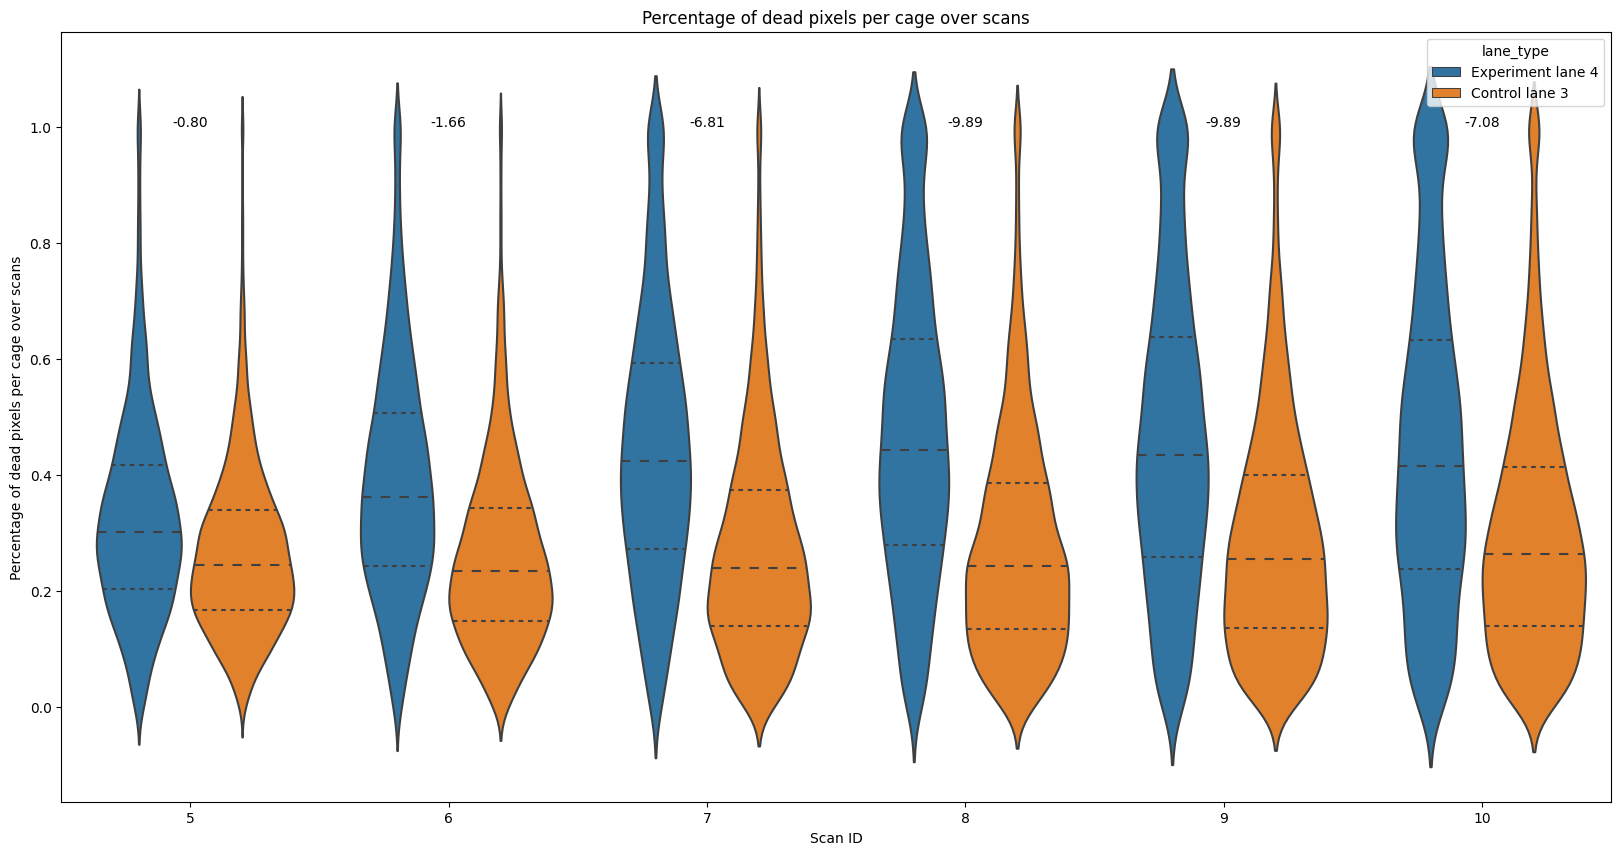

In [105]:
df_for_plot = pd.DataFrame(columns = ['cage_id', 'scan_id', 'num_cells', 'Percentage dead pixels', 'Max percentage dead pixels', 'lane_type'])
for scan_id in [SCAN_ID_FOR_INSTANCE_SEGMENTATION] + SCAN_IDS:
    scan_id_df = pd.concat(
        [exp_df[[scan_id, 'num_cells', 'max_scan', 'lane_type']].rename(columns={scan_id:'Percentage dead pixels',
                                                                                'max_scan': 'Max percentage dead pixels'}).reset_index(),
         control_df[[scan_id, 'num_cells', 'max_scan', 'lane_type']].rename(columns={scan_id:'Percentage dead pixels',
                                                                                     'max_scan': 'Max percentage dead pixels'}).reset_index()]
    ).reset_index(drop=True)
    scan_id_df['scan_id'] = scan_id
    df_for_plot = pd.concat(
        [df_for_plot, scan_id_df]
    ).reset_index(drop=True)
    

if BOTH_CONTROL_LANES:
    exp_lane_type_str: str = 'Control lane ' + str(EXP_LANE_TO_USE)
    control_lane_type_str = 'Control lane ' + str(CONTROL_LANE_TO_USE)
else:
    exp_lane_type_str: str = 'Experiment lane ' + str(EXP_LANE_TO_USE)
    control_lane_type_str: str = 'Control lane ' + str(CONTROL_LANE_TO_USE)

df_for_plot.loc[df_for_plot['lane_type'] == 'Experiment', 'lane_type'] = exp_lane_type_str
df_for_plot.loc[df_for_plot['lane_type'] == 'Control', 'lane_type'] = control_lane_type_str

k_s_p_values: List[float] = []
# Kolmogorov-Smirnov (K-S) goodness-of-fit test
for scan_id in [SCAN_ID_FOR_INSTANCE_SEGMENTATION] + SCAN_IDS:
    x = exp_df[scan_id].values
    y = control_df[scan_id].values
    # subtract the means and normalize both samples with standard deviation to only compare the shapes of the distributions
    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)
    test_results = ks_2samp(x, y)
    k_s_p_values.append(test_results.pvalue)

# create violin plot
fig, ax = plt.subplots(1, figsize=(20, 10))
sn_plot = sn.violinplot(data=df_for_plot, x='scan_id', y='Percentage dead pixels', hue='lane_type', inner="quartile")

for i in range(len(k_s_p_values)):
    plt.text(i, int(df_for_plot['Percentage dead pixels'].max()), f'{np.log10(k_s_p_values[i]):.2f}', ha='center', color='black')

# ax.set_aspect('equal')
# ax.legend(bbox_to_anchor=(0.9, 0.95), loc=1, borderaxespad=0.0)
plt.xlabel('Scan ID')
plt.ylabel(f"Percentage of dead pixels per cage over scans")
plt.title(f"Percentage of dead pixels per cage over scans")

plt.show()

Text(0.5, 1.0, 'The maximum percentage dead pixels over scans per cage')

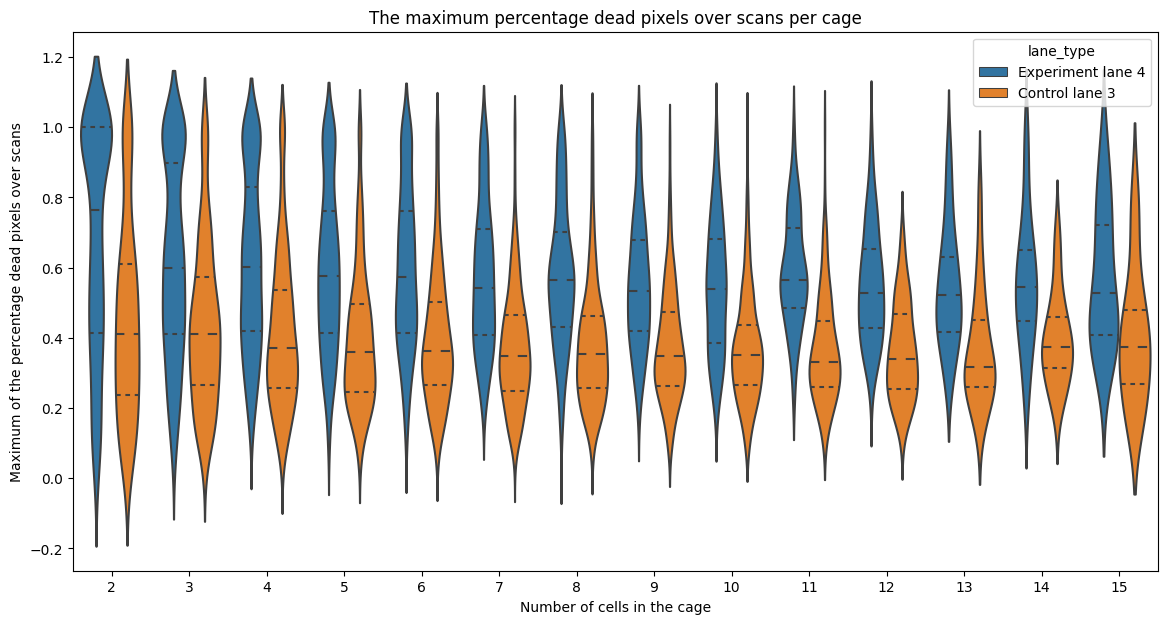

In [116]:
df_for_plot[['cage_id', 'num_cells', 'Max percentage dead pixels', 'lane_type']].drop_duplicates()

# Create violin plot
fig, ax = plt.subplots(1, figsize=(14, 7))
sn_plot = sn.violinplot(data=df_for_plot[['cage_id', 'num_cells', 'Max percentage dead pixels', 'lane_type']].drop_duplicates(), 
                        x='num_cells', y='Max percentage dead pixels', hue='lane_type', inner="quartile", 
                        order = [i for i in range(NUM_CELLS_RANGE[0], NUM_CELLS_RANGE[1])]
                       )
# ax.set_aspect('equal')
# ax.legend(bbox_to_anchor=(0.9, 0.95), loc=1, borderaxespad=0.0)
plt.xlabel('Number of cells in the cage')
plt.ylabel('Maximum of the percentage dead pixels over scans')
plt.title('The maximum percentage dead pixels over scans per cage')

/tmp/ipykernel_483904/727388808.py:18: RuntimeWarning: divide by zero encountered in log10
  p_values[i] = np.round(np.log10(p_value), 2)
/tmp/ipykernel_483904/727388808.py:18: RuntimeWarning: divide by zero encountered in log10
  p_values[i] = np.round(np.log10(p_value), 2)


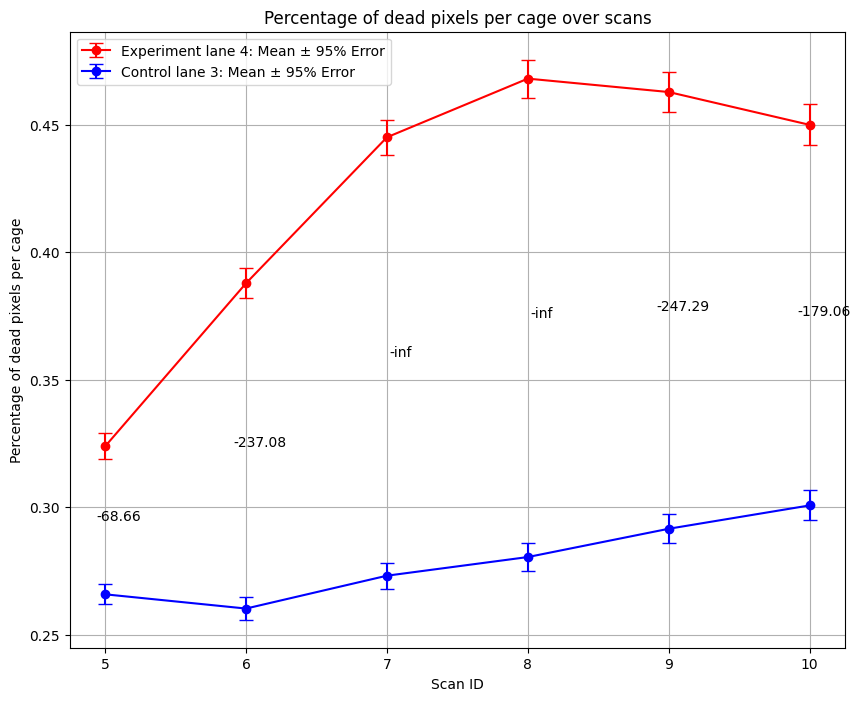

In [34]:
# Calculate mean and standard deviation for each column
control_means = np.mean(control_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].values, axis=0)
control_std_devs = np.std(control_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].values, axis=0)
num_control_samples = len(control_df)

exp_means = np.mean(exp_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].values, axis=0)
exp_std_devs = np.std(exp_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].values, axis=0)
num_exp_samples = len(exp_df)

x = SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS

p_values = np.zeros_like(x, dtype=float)
for i, scan_id in enumerate(x):
    set_1 = control_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].values[:, i]
    set_2 = exp_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].values[:, i]
    # Welch's t-test
    t_statistic, p_value = ttest_ind(set_1, set_2, equal_var=False)
    p_values[i] = np.round(np.log10(p_value), 2)

fig, ax = plt.subplots(1, figsize=(10, 8))

if BOTH_CONTROL_LANES:
    exp_label = 'Control lane ' + str(EXP_LANE_TO_USE) + ': Mean ± 95% Error'
    control_label = 'Control lane ' + str(CONTROL_LANE_TO_USE) + ': Mean ± 95% Error'
else:
    exp_label = 'Experiment lane ' + str(EXP_LANE_TO_USE) + ': Mean ± 95% Error'
    control_label = 'Control lane ' + str(CONTROL_LANE_TO_USE) + ': Mean ± 95% Error'

# Plot mean with error bars representing standard deviation
plt.errorbar(x, exp_means, yerr=1.96 * exp_std_devs / np.sqrt(num_exp_samples), fmt='r-o', capsize=5, label=exp_label)
plt.errorbar(x, control_means, yerr=1.96 * control_std_devs / np.sqrt(num_control_samples), fmt='b-o', capsize=5, label=control_label)

for i in range(len(x)):
    plt.text(x[i]+0.1, (exp_means[i] + control_means[i]) / 2, f'{p_values[i]:.2f}', ha='center', color='black')


# Add labels and title
plt.xlabel('Scan ID')
plt.ylabel(f"Percentage of dead pixels per cage")
plt.title(f"Percentage of dead pixels per cage over scans")
plt.legend()
plt.grid(True)
plt.show()

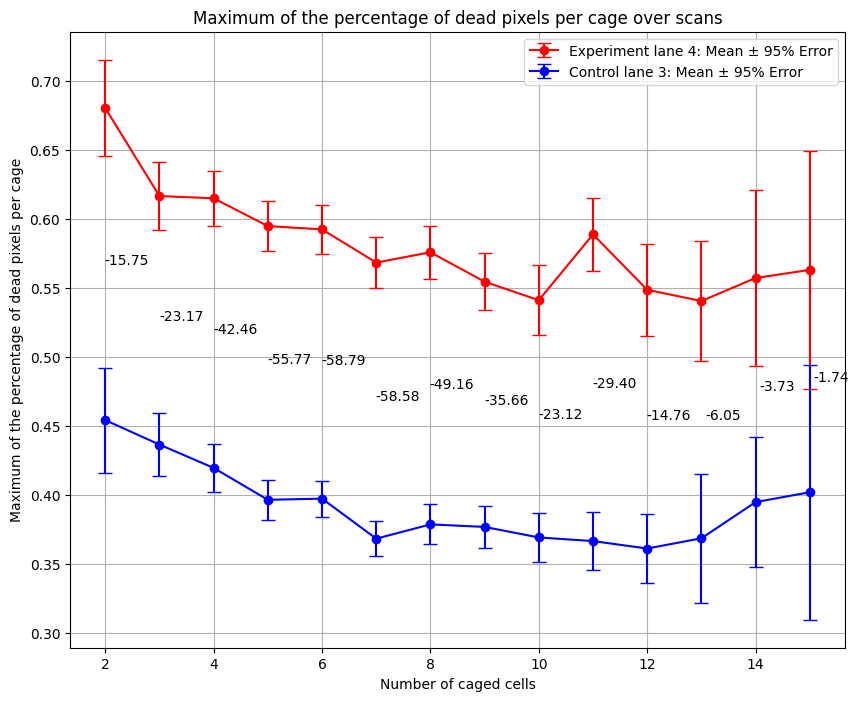

In [35]:
# Calculate mean and standard deviation for each column
control_means = control_df.groupby('num_cells')['max_scan'].mean()
control_std_devs = control_df.groupby('num_cells')['max_scan'].std()
control_means = control_means[(NUM_CELLS_RANGE[0] <= control_means.index) & (control_means.index < NUM_CELLS_RANGE[1])]
control_std_devs = control_std_devs[control_means.index]
num_control_samples = control_df.groupby('num_cells')['num_cells'].apply(len)
num_control_samples = num_control_samples[control_means.index]

exp_means = exp_df.groupby('num_cells')['max_scan'].mean()
exp_std_devs = exp_df.groupby('num_cells')['max_scan'].std()
exp_means = exp_means[(NUM_CELLS_RANGE[0] <= exp_means.index) & (exp_means.index < NUM_CELLS_RANGE[1])]
exp_std_devs = exp_std_devs[exp_means.index]
num_exp_samples = exp_df.groupby('num_cells')['num_cells'].apply(len)
num_exp_samples = num_exp_samples[exp_means.index]

control_cage_counts = control_df.groupby('num_cells')['max_scan'].apply(len)
exp_cage_counts = exp_df.groupby('num_cells')['max_scan'].apply(len)

# Create an x-axis for each column
p_values = np.zeros_like(exp_means.index, dtype=float)
for i, num_cells in enumerate(exp_means.index):
    set_1 = control_df.groupby('num_cells')['max_scan'].get_group(num_cells).values
    set_2 = exp_df.groupby('num_cells')['max_scan'].get_group(num_cells).values
    # Welch's t-test
    t_statistic, p_value = ttest_ind(set_1, set_2, equal_var=False)
    p_values[i] = np.log10(p_value)

if BOTH_CONTROL_LANES:
    exp_label = 'Control lane ' + str(EXP_LANE_TO_USE) + ': Mean ± 95% Error'
    control_label = 'Control lane ' + str(CONTROL_LANE_TO_USE) + ': Mean ± 95% Error'
else:
    exp_label = 'Experiment lane ' + str(EXP_LANE_TO_USE) + ': Mean ± 95% Error'
    control_label = 'Control lane ' + str(CONTROL_LANE_TO_USE) + ': Mean ± 95% Error'

x = exp_means.index
fig, ax = plt.subplots(1, figsize=(10, 8))
# Plot mean with error bars representing standard deviation
plt.errorbar(x, exp_means, yerr=1.95 * exp_std_devs.div(num_exp_samples.apply(np.sqrt)), fmt='r-o', capsize=5, label=exp_label)
plt.errorbar(x, control_means, yerr=1.95 * control_std_devs.div(num_control_samples.apply(np.sqrt)), fmt='b-o', capsize=5, label=control_label)

for i in range(len(x)):
    plt.text(x[i]+0.4, (exp_means[x[i]] + control_means[x[i]]) / 2, f'{p_values[i]:.2f}', ha='center', color='black')


# Add labels and title
# Add labels and title
plt.xlabel('Number of caged cells')
plt.ylabel(f"Maximum of the percentage of dead pixels per cage")
plt.title(f"Maximum of the percentage of dead pixels per cage over scans")
plt.legend()
plt.grid(True)

In [54]:
PICK_MAXIMUM = False
if PICK_MAXIMUM: 
    exp_df = exp_df.sort_values(
        by=['max_scan'],
        ascending=False,
        ignore_index=False
    )

    control_df = control_df.sort_values(
        by=['max_scan'],
        ascending=False,
        ignore_index=False
    )

else:


    # replace the metric value for the later scans with the maximum observed during the experiment
    for i, row in exp_df.iterrows():
        for column in SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS:
            if column > row['max_scan_id']:
                exp_df.loc[i, column] = row['max_scan']

    for i, row in control_df.iterrows():
        for column in SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS:
            if column > row['max_scan_id']:
                control_df.loc[i, column] = row['max_scan']
    
    exp_df = exp_df.sort_values(
        by=[10, 9, 8, 7, 6, 5],
        ascending=False,
        ignore_index=False
    )

    control_df = control_df.sort_values(
        by=[10, 9, 8, 7, 6, 5],
        ascending=False,
        ignore_index=False
    )

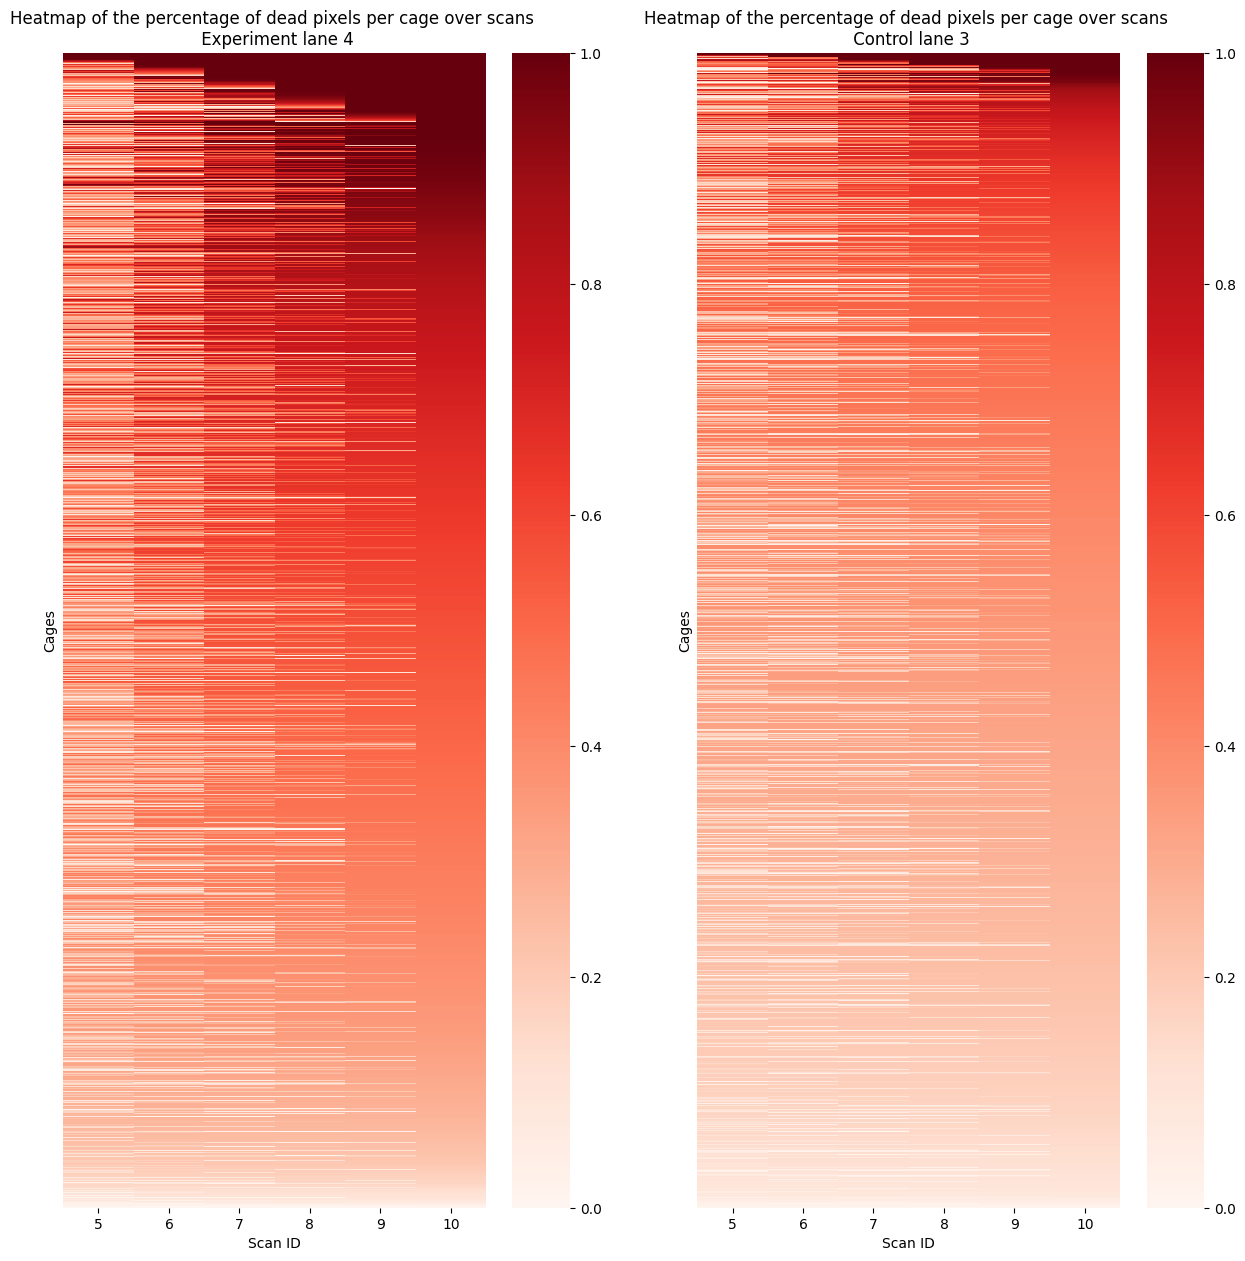

In [55]:
norm = Normalize(vmin=min(exp_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].min().min(), 
                          control_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].min().min()), 
                 vmax=max(exp_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].max().max(), 
                          control_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS].max().max()))

fig, ax = plt.subplots(1, 2, figsize=(15, 15))
# create data

if PICK_MAXIMUM:
    sn.heatmap(exp_df[['max_scan']], annot=False, yticklabels=False, ax=ax[0], cmap='Reds', norm=norm)
    ax[0].set_title(f"Heatmap of the maximum of the percentage of dead pixels per cage \n over scans: Experiment lane {EXP_LANE_TO_USE}") 
else:
    sn.heatmap(exp_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS], annot=False, yticklabels=False, ax=ax[0], cmap='Reds', norm=norm)
    ax[0].set_title(f"Heatmap of the percentage of dead pixels per cage over scans \n Experiment lane {EXP_LANE_TO_USE}") 
    
ax[0].set(ylabel='Cages', xlabel='Scan ID')

if PICK_MAXIMUM:
    sn.heatmap(control_df[['max_scan']], annot=False, yticklabels=False, ax=ax[1], cmap='Reds', norm=norm)
    ax[1].set_title(f"Heatmap of the maximum of the percentage of dead pixels per cage \n over scans: Control lane {CONTROL_LANE_TO_USE}") 
else:
    sn.heatmap(control_df[SCAN_IDS_FOR_PERCENTAGE_DEAD_CELLS], annot=False, yticklabels=False, ax=ax[1], cmap='Reds', norm=norm)
    ax[1].set_title(f"Heatmap of the percentage of dead pixels per cage over scans \n Control lane {CONTROL_LANE_TO_USE}") 

ax[1].set(ylabel='Cages', xlabel='Scan ID')
plt.show()

In [ ]:
COLORS = {'Red': np.array([255, 0, 0]), 
         'Green': np.array([0, 255, 0]), 
         'Blue': np.array([0, 0, 255])}

from helper_utils import get_cage_crop

In [ ]:
ref_img_with_mask_rcnn_masks, img_with_cell_masks, img_overlay = get_cage_crop(
    merged_cages_metrics=exp_merged_cages_metrics, 
    exp_base_path=EXP_BASE_PATH, 
    ref_scan_id=SCAN_ID_FOR_INSTANCE_SEGMENTATION,
    scan_id=10, 
    lane_id=EXP_LANE_TO_USE, 
    cage_id=3, 
    fl_channel_identifiers=FL_CHANNELS_LIST,
    thresholds_for_pixel_classification = fl_thresholds, 
    inst_segmentor_model=inst_segmentor,
    sem_segmentor_model=sem_segmentor, 
    colors=COLORS
)

In [ ]:
Image.fromarray(ref_img_with_mask_rcnn_masks)

In [ ]:
Image.fromarray(img_with_cell_masks)

In [ ]:
Image.fromarray(img_overlay)

In [ ]:
import random
def get_plots(merged_cages_metrics: Dict[str, pd.DataFrame], ordered_cage_ids: List[int], num_samples_to_consider: int, is_control: bool):
    
    ref_mask_rcnn: Dict[int, List[np.ndarray]] = {}
    img_overlays: Dict[int, List[np.ndarray]] = {}
    max_metrics: Dict[int, List[float]] = {}
    
    for cage_id in ordered_cage_ids:

        num_cells: int = merged_cages_metrics['all'].loc[merged_cages_metrics['all']['cage_id'] == cage_id, 'num_cells'].unique()[0]

        if num_cells < NUM_CELLS_RANGE[0] or num_cells > NUM_CELLS_RANGE[1]:
            continue

        if num_cells in img_overlays:
            if len(img_overlays[num_cells]) >= num_samples_to_consider:
                continue
        else:
            img_overlays[num_cells] = []
            ref_mask_rcnn[num_cells] = []
            max_metrics[num_cells] = []
    
        scan_id = merged_cages_metrics['all'].loc[
        merged_cages_metrics['all']['cage_id'] == cage_id,'scan_id_with_highest_' + METRIC_TO_USE
        ].unique()[0]

        # pick the ones that happen over 8, 9, and 10
        if scan_id < 8:
            continue

        max_metric = merged_cages_metrics['all'].loc[
        merged_cages_metrics['all']['cage_id'] == cage_id,'highest_' + METRIC_TO_USE + '_over_scans'
        ].unique()[0]

        ref_img_with_mask_rcnn_masks, img_with_cell_masks, img_overlay = get_cage_crop(
            merged_cages_metrics=merged_cages_metrics, 
            exp_base_path=EXP_BASE_PATH, 
            ref_scan_id=SCAN_ID_FOR_INSTANCE_SEGMENTATION,
            scan_id=scan_id, 
            lane_id=CONTROL_LANE_TO_USE if is_control else EXP_LANE_TO_USE, 
            cage_id=cage_id, 
            fl_channel_identifiers=FL_CHANNELS_LIST,
            thresholds_for_pixel_classification=fl_thresholds,
            inst_segmentor_model=inst_segmentor,
            sem_segmentor_model=sem_segmentor,
            colors=COLORS
        )
        ref_mask_rcnn[num_cells].append(ref_img_with_mask_rcnn_masks)
        img_overlays[num_cells].append(img_overlay)
        max_metrics[num_cells].append(max_metric)

    return ref_mask_rcnn, img_overlays, max_metrics


def get_plots(merged_cages_metrics: Dict[str, pd.DataFrame], num_samples_to_consider: int, is_control: bool):
    
    ref_mask_rcnn: Dict[int, List[np.ndarray]] = {}
    img_overlays: Dict[int, List[np.ndarray]] = {}
    max_metrics: Dict[int, List[float]] = {}
    
    for num_cells in range(NUM_CELLS_RANGE[0], NUM_CELLS_RANGE[1]):

        img_overlays[num_cells] = []
        ref_mask_rcnn[num_cells] = []
        max_metrics[num_cells] = []
        
        unique_cage_ids = merged_cages_metrics['all'].loc[
        merged_cages_metrics['all']['num_cells'] == num_cells, 'cage_id'
        ].unique()
        # shuffle the cage_ids and pick randomly 10
        random.shuffle(unique_cage_ids)
        unique_cage_ids = unique_cage_ids[:max(num_samples_to_consider, int(0.2 * len(unique_cage_ids)))]
        # order the cage IDs based on their higher metric score over scans and then pick the top num_samples_to_consider

        all_max_metrics = np.zeros((len(unique_cage_ids),))
        
        for i, cage_id in enumerate(unique_cage_ids):
            all_max_metrics[i] = merged_cages_metrics['all'].loc[
            merged_cages_metrics['all']['cage_id'] == cage_id,'highest_' + METRIC_TO_USE + '_over_scans'
            ].unique()[0]
            
        idxs_to_consider = np.argsort(-all_max_metrics)[:num_samples_to_consider]  

        for idx in idxs_to_consider:
            
            cage_id = unique_cage_ids[idx]
            max_metric = all_max_metrics[idx]
            
            scan_id = merged_cages_metrics['all'].loc[
            merged_cages_metrics['all']['cage_id'] == cage_id,'scan_id_with_highest_' + METRIC_TO_USE
            ].unique()[0]

            ref_img_with_mask_rcnn_masks, img_with_cell_masks, img_overlay = get_cage_crop(
                merged_cages_metrics=merged_cages_metrics, 
                exp_base_path=EXP_BASE_PATH, 
                ref_scan_id=SCAN_ID_FOR_INSTANCE_SEGMENTATION,
                scan_id=scan_id, 
                lane_id=CONTROL_LANE_TO_USE if is_control else EXP_LANE_TO_USE, 
                cage_id=cage_id, 
                fl_channel_identifiers=FL_CHANNELS_LIST,
                thresholds_for_pixel_classification=fl_thresholds,
                inst_segmentor_model=inst_segmentor,
                sem_segmentor_model=sem_segmentor,
                colors=COLORS
            )
            ref_mask_rcnn[num_cells].append(ref_img_with_mask_rcnn_masks)
            img_overlays[num_cells].append(img_overlay)
            max_metrics[num_cells].append(max_metric)

    return ref_mask_rcnn, img_overlays, max_metrics

In [ ]:
NUM_SAMPLES_TO_CONSIDER = 2
exp_ref_mask_rcnn, exp_img_overlay, exp_max_matrics = get_plots(merged_cages_metrics=exp_merged_cages_metrics, 
                                               # ordered_cage_ids = exp_df.index.values.tolist(),
                                               num_samples_to_consider=NUM_SAMPLES_TO_CONSIDER, 
                                               is_control=False)

# exp_ref_mask_rcnn = {k:exp_ref_mask_rcnn[k] for k in sorted(exp_ref_mask_rcnn.keys())}
# exp_img_overlay = {k:exp_img_overlay[k] for k in exp_ref_mask_rcnn}
# exp_max_matrics = {k: exp_max_matrics[k] for k in exp_ref_mask_rcnn}

In [ ]:
control_ref_mask_rcnn, control_img_overlay, control_max_metrics = get_plots(merged_cages_metrics=control_merged_cages_metrics, 
                                                       # ordered_cage_ids = control_df.index.values.tolist(),
                                                       num_samples_to_consider=NUM_SAMPLES_TO_CONSIDER,
                                                       is_control=True)
# control_ref_mask_rcnn = {k:control_ref_mask_rcnn[k] for k in sorted(control_ref_mask_rcnn.keys())}
# control_img_overlay = {k:control_img_overlay[k] for k in control_ref_mask_rcnn}
# control_max_metrics = {k: control_max_metrics[k] for k in control_ref_mask_rcnn}

In [ ]:
images = []
for k, v in exp_img_overlay.items():
    for i in range(NUM_SAMPLES_TO_CONSIDER):
        images = images + [exp_ref_mask_rcnn[k][i]]
        images = images + [v[i]]
out_exp = create_image_grid(images, (NUM_CELLS_RANGE[1] - NUM_CELLS_RANGE[0], 2 * NUM_SAMPLES_TO_CONSIDER), (224, 224))

images = []
for k, v in control_img_overlay.items():
    for i in range(NUM_SAMPLES_TO_CONSIDER):
        images = images + [control_ref_mask_rcnn[k][i]]
        images = images + [v[i]]
out_control = create_image_grid(images, (NUM_CELLS_RANGE[1] - NUM_CELLS_RANGE[0], 2 * NUM_SAMPLES_TO_CONSIDER), (224, 224))

In [ ]:
Image.fromarray(out_exp)

In [ ]:
Image.fromarray(out_control)

In [ ]:
exp_max_matrics

In [ ]:
control_max_metrics

In [ ]:
bins = np.array([i for i in range(10)]) - 0.5

# Calculate the histogram of the number of effector cells for both lanes
# can use this value as well exp_merged_cages_metrics['Blue_negative'][['cage_id', 'num_cells']].drop_duplicates()['num_cells'] 
# as the number of cells in the cage are coming from the first scan for all the following scans
hist1, _ = np.histogram(
    exp_merged_cages_metrics['Blue_negative'].groupby('scan_id').get_group(SCAN_ID_FOR_INSTANCE_SEGMENTATION)['num_cells'].values,
    bins=bins, density=True
)
hist2, _ = np.histogram(
    control_merged_cages_metrics['Blue_negative'].groupby('scan_id').get_group(SCAN_ID_FOR_INSTANCE_SEGMENTATION)['num_cells'].values,
    bins=bins, density=True
)

# Define the width of each bar and the positions for parallel bars
bar_width = 0.4
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Plot the first histogram
plt.bar(bin_centers - bar_width / 2, hist1, width=bar_width, label=exp_label, color='blue', alpha=0.7)

# Plot the second histogram
plt.bar(bin_centers + bar_width / 2, hist2, width=bar_width, label=control_label, color='orange', alpha=0.7)

# Add labels and legend
plt.xlabel('Number of Effector caged cells')
plt.ylabel('Density')
plt.legend()
plt.title(f"Histogram of the number of Effector cells (CFSE negative) per cage")
plt.show()

In [ ]:
import seaborn as sn
log_data = {}
for fl_channel_identifier in ['Blue', 'Red']:
    data = np.array(avg_fl_signal_per_cell[fl_channel_identifier])
    # replace the zero values with the smallest none-zero
    min_non_zero_data_value = np.min(data[data > 0])
    data[data == 0] = min_non_zero_data_value
    # logarithmic scale
    log_data[fl_channel_identifier] = np.log10(data)

fig, ax = plt.subplots(1, figsize=(10, 10))
sn_plot = sn.scatterplot(data=pd.DataFrame({'Blue': log_data['Blue'], 
                                            'Red': log_data['Red']}), x='Blue', y='Red',  marker="+")